## This notebook will describe the analysis for 
# Our comparitive analysis of the different population estimation approaches 

Rose Foster-Dyer   
Updated 02.09.2026
___ 

### Data types available (2024, 2025)
- SAR-derived breeding pairs (one count per year from midwinter) 
- SAR-derived individuals (one count per month through winter)
- VHR-derived abundance index using bayesian model (one per year from spring)
- VHR-derived abundance index using windchill model (one per year from spring)
- chick counts (available for four sites)
- adult counts (available from just one site (Crozier))

I first plan to create a figure for each site, one panel per year (2024 and 2025) with all data sources included 

I also want to create a simple table showing the data available per type per year. 


I will also perform some simple statistical analyses to compare the results produced through each method. 

___

This paper will be prepared for Conservation Letters or something similar, and will be presented as a caution of the conclusions that can be drawn from a singular population estimation approach. 

___ 

This will use methods described in:   
- Foster-Dyer et al. "Midwinter radar imaging establishes first breeding population baseline for the endangered emperor penguin" submitted to RSEC 
- LaRue et al. 2024 "Advances in remote sensing..." Proc B. 
- Foster-Dyer et al. 2026 "Evidence of emperor penguins sensitivity to sea ice fluctuations" Proc B. 
- Winterl et al. 2024 "Remote sensing and emperor penguins..." Nature Comms. 

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from scipy import stats
from scipy.optimize import minimize
from sklearn.utils import resample

In [2]:
# Loading data 

INPUTPATH = "/mnt/c/Users/rfo37/OneDrive - University of Canterbury/Github/SAR_RossSea_compare/SAR_RossSea_compare/"

df_RossSea = pd.read_csv(os.path.join(INPUTPATH, "Data/RS_pops2425_combined.csv"))


In [3]:
df_RossSea.info()
df_RossSea.head()

<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   colony         158 non-null    str    
 1   site_id        158 non-null    str    
 2   type           158 non-null    str    
 3   date           155 non-null    str    
 4   month          155 non-null    float64
 5   day            155 non-null    float64
 6   year           158 non-null    int64  
 7   DOY            158 non-null    float64
 8   lat            158 non-null    float64
 9   lon            158 non-null    float64
 10  count          149 non-null    float64
 11  count_se       139 non-null    float64
 12  method         158 non-null    str    
 13  notes          28 non-null     str    
 14  phenology_est  104 non-null    str    
dtypes: float64(7), int64(1), str(7)
memory usage: 26.3 KB


,colony,site_id,type,date,month,day,year,DOY,lat,lon,count,count_se,method,notes,phenology_est
0,Crozier,CROZ,adults,21/11/2024,11.0,21.0,2024,325.0,-77.452742,169.275066,1075.0,NaN,adults,"Annie Schmidt, Grant Ballard",NaN
1,Crozier,CROZ,adults,22/11/2025,11.0,22.0,2025,326.0,-77.452742,169.275066,627.0,NaN,adults,"Annie Schmidt, Grant Ballard",NaN
2,Coulman,COUL,chicks,21/11/2024,11.0,21.0,2024,325.0,-73.350000,169.610000,21242.0,NaN,chicks,Jeong-Hoon Kim,NaN
3,Coulman,COUL,chicks,6/12/2025,12.0,6.0,2025,340.0,-73.350000,169.610000,6686.0,NaN,chicks,Jeong-Hoon Kim,NaN
4,Crozier,CROZ,chicks,21/11/2024,11.0,21.0,2024,325.0,-77.452742,169.275066,2773.0,NaN,chicks,"Annie Schmidt, Grant Ballard",NaN


In [4]:
df_RossSea.columns

Index(['colony', 'site_id', 'type', 'date', 'month', 'day', 'year', 'DOY',
       'lat', 'lon', 'count', 'count_se', 'method', 'notes', 'phenology_est'],
      dtype='str')

In [5]:
df_RossSea[df_RossSea['year'].isna()]

,colony,site_id,type,date,month,day,year,DOY,lat,lon,count,count_se,method,notes,phenology_est


In [6]:
# Convert the 'year' column to integers
df_RossSea['year'] = df_RossSea['year'].astype(int)


In [7]:
#creating categories for plotting
df_RossSea = df_RossSea.astype({
    'method': 'category',
    'type': 'category',
    'colony': 'category',
    'year': 'category', 
    'notes': 'category'
})

In [8]:
# Loop through your categorical columns
for col in ['colony', 'type', 'method', 'year', 'notes']:
    print(f"\nLevels in '{col}':")
    print(list(df_RossSea[col].cat.categories))


Levels in 'colony':
['Beaufort', 'Colbeck', 'Coulman', 'Crozier', 'Franklin', 'Roget', 'Washington']

Levels in 'type':
['abundance index', 'adults', 'breeding pairs', 'chicks', 'individuals']

Levels in 'method':
['SAR', 'SAR-bp', 'VHR-bayes', 'VHR-rho', 'adults', 'chicks']

Levels in 'year':
[2024, 2025]

Levels in 'notes':
['Annie Schmidt, Grant Ballard', 'Jeong-Hoon Kim ', 'birds too dispersed to quantify', 'colony', 'combined', 'iceberg', 'no VHR image acquired in 2024, doy taken from 2025', 'no birds visible']


## Another thing to consider is the different counts at Coulman in 2025 

I have quantified both the group of birds up on the iceberg as well as those down at the colony, and then i have also quantified the total combined number.   

I think we should move forward with only the combined value, so need to subset that out and proceed with that df as the one to plot.   


But there is value in the different number for each group, and I think it would be an interesting discussion point about how many birds were up on the iceberg still in September. Also making the point of how this relates to the resulting chick count (Park et al. 2026)

In [10]:
# Exclude 'iceberg' and 'colony' data from 'notes' row in Coulman 2025 data and move forward with a dataset without those datapoint, to be added back in for other parts of the analysis. 

# We need to identify the rows that are coulman, 2025 and VHR-bayes

# Select rows where: ( I didn't need to select these, just use the conditione exclude definition)
# - colony == 'Coulman' 
# - method == 'VHR-bayes'
# - year == 2025
# AND exclude rows where 'notes' == 'colony' or 'iceberg'

#condition_include = (df_RossSea['colony']== "Coulman") & (df_RossSea['method'] == 'VHR-bayes') & (df_RossSea['year'] == 2025)
condition_exclude = (df_RossSea['notes'] == 'colony') | (df_RossSea['notes'] == 'iceberg')

df_RossSea = df_RossSea[#condition_include & 
    ~condition_exclude]

print(df_RossSea)



         colony site_id             type        date  month   day  year  \
0       Crozier    CROZ           adults  21/11/2024   11.0  21.0  2024   
1       Crozier    CROZ           adults  22/11/2025   11.0  22.0  2025   
2       Coulman    COUL           chicks  21/11/2024   11.0  21.0  2024   
3       Coulman    COUL           chicks   6/12/2025   12.0   6.0  2025   
4       Crozier    CROZ           chicks  21/11/2024   11.0  21.0  2024   
..          ...     ...              ...         ...    ...   ...   ...   
153    Franklin    FRAN  abundance index  24/10/2025   10.0  24.0  2025   
154       Roget    ROGE  abundance index  22/10/2025   10.0  22.0  2025   
155       Roget    ROGE  abundance index  11/10/2024   10.0  11.0  2024   
156  Washington    WASH  abundance index  27/10/2024   10.0  27.0  2024   
157  Washington    WASH  abundance index   1/11/2025   11.0   1.0  2025   

       DOY        lat         lon     count     count_se   method  \
0    325.0 -77.452742  169.275

# Creating a figure that shows the year long cycle of population change for Ross Sea colonies 

(these ideas were written back in April)

Also incorporate chick counts, a line to identify the point at which the iceberg arrived at Coulman 

And possibly change shapes of points depending on estimate phenological stage 


- Arrival/Courtship  
- Mating 
- Female departure 
- Peak male huddle  
- Female return  

Should we also include the 2024 data from the Ross Sea? 
- Crozier 
- Washington? Roget? 
- Coulman 

In [11]:
## I want to make a simple summary statistics table, report the max value for each year for each data type, I wonder if i can include slope in it. 

summary_stats = (
    df_RossSea
    .groupby(['method', 'colony', 'year'])['count']
    .agg(
        max_count='max',
        min_count='min'
    )
    .reset_index()
)

summary_stats

,method,colony,year,max_count,min_count
0,SAR,Beaufort,2025,631.52000,563.95000
1,SAR,Colbeck,2025,40270.80000,16744.86000
2,SAR,Coulman,2024,29189.22000,11948.89000
3,SAR,Coulman,2025,29584.92000,6408.62000
4,SAR,Crozier,2024,5185.81000,1574.11000
5,SAR,Crozier,2025,4501.43000,1543.15000
6,SAR,Franklin,2024,14988.76000,749.77000
7,SAR,Franklin,2025,7647.72000,3965.16000
8,SAR,Roget,2024,12833.16000,3712.12000
9,SAR,Roget,2025,9882.92000,2978.64000


In [12]:
## Creating a summary table for the totals from each method: 

total_summary = (
    df_RossSea
    .groupby(['method', 'year'])
    .agg(
        total_population=('count', 'sum'),
        n_colonies=('colony', 'nunique')
    )
    .reset_index()
)

total_summary

,method,year,total_population,n_colonies
0,SAR,2024,543556.65000,5
1,SAR,2025,600709.79000,7
2,SAR-bp,2024,39358.60000,5
3,SAR-bp,2025,62999.48000,7
4,VHR-bayes,2024,52505.87618,7
5,VHR-bayes,2025,51885.18000,7
6,VHR-rho,2024,167174.65000,3
7,VHR-rho,2025,334363.62000,7
8,adults,2024,1075.00000,1
9,adults,2025,627.00000,1


In [13]:
# 1. Peak SAR value for each colony-year
sar_peak = (
    df_RossSea[df_RossSea['method'] == 'SAR']
    .groupby(['colony', 'year'], as_index=False)['count']
    .max()
    .assign(method='SAR')
)

# 2. All non-SAR observations
other_methods = (
    df_RossSea[df_RossSea['method'] != 'SAR']
    [['method', 'colony', 'year', 'count']]
    .copy()
)

# 3. Combine them
colony_year_summary = pd.concat(
    [sar_peak[['method', 'colony', 'year', 'count']],
     other_methods],
    ignore_index=True
)

# 4. Calculate summary statistics across colonies
summary_table = (
    colony_year_summary
    .groupby(['method', 'year'])
    .agg(
        n_colonies=('colony', 'nunique'),
        total_population=('count', 'sum'),
        mean=('count', 'mean'),
        median=('count', 'median'),
        sd=('count', 'std'),
        minimum=('count', 'min'),
        maximum=('count', 'max')
    )
    .reset_index()
)

# 5. Create a range column
summary_table['range'] = (
    summary_table['minimum'].round(0).astype(int).astype(str)
    + '–' +
    summary_table['maximum'].round(0).astype(int).astype(str)
)

# 6. Keep the columns in a sensible reporting order
summary_table = summary_table[
    ['method', 'year', 'n_colonies', 'total_population',
     'mean', 'median', 'sd', 'range']
]

summary_table

,method,year,n_colonies,total_population,mean,median,sd,range
0,SAR,2024,5,82627.49000,16525.498000,14988.76,8947.103658,5186–29189
1,SAR,2025,7,115801.58000,16543.082857,9882.92,14720.593319,632–40271
2,SAR-bp,2024,5,39358.60000,7871.720000,5261.45,5563.396665,2350–16376
3,SAR-bp,2025,7,62999.48000,8999.925714,7252.01,7695.622738,564–21418
4,VHR-bayes,2024,7,52505.87618,7500.839454,4382.11,8220.828087,293–23822
5,VHR-bayes,2025,7,51885.18000,7412.168571,4049.60,8187.126498,274–23619
6,VHR-rho,2024,3,167174.65000,55724.883333,46595.07,34191.091954,27025–93554
7,VHR-rho,2025,7,334363.62000,47766.231429,21047.74,57381.461091,1198–160988
8,adults,2024,1,1075.00000,1075.000000,1075.00,NaN,1075–1075
9,adults,2025,1,627.00000,627.000000,627.00,NaN,627–627


## Simple exploratory plot 

I want to first create a simple exploratory plot for each site, for each method, maybe one panel per method, with different colours for each year? 



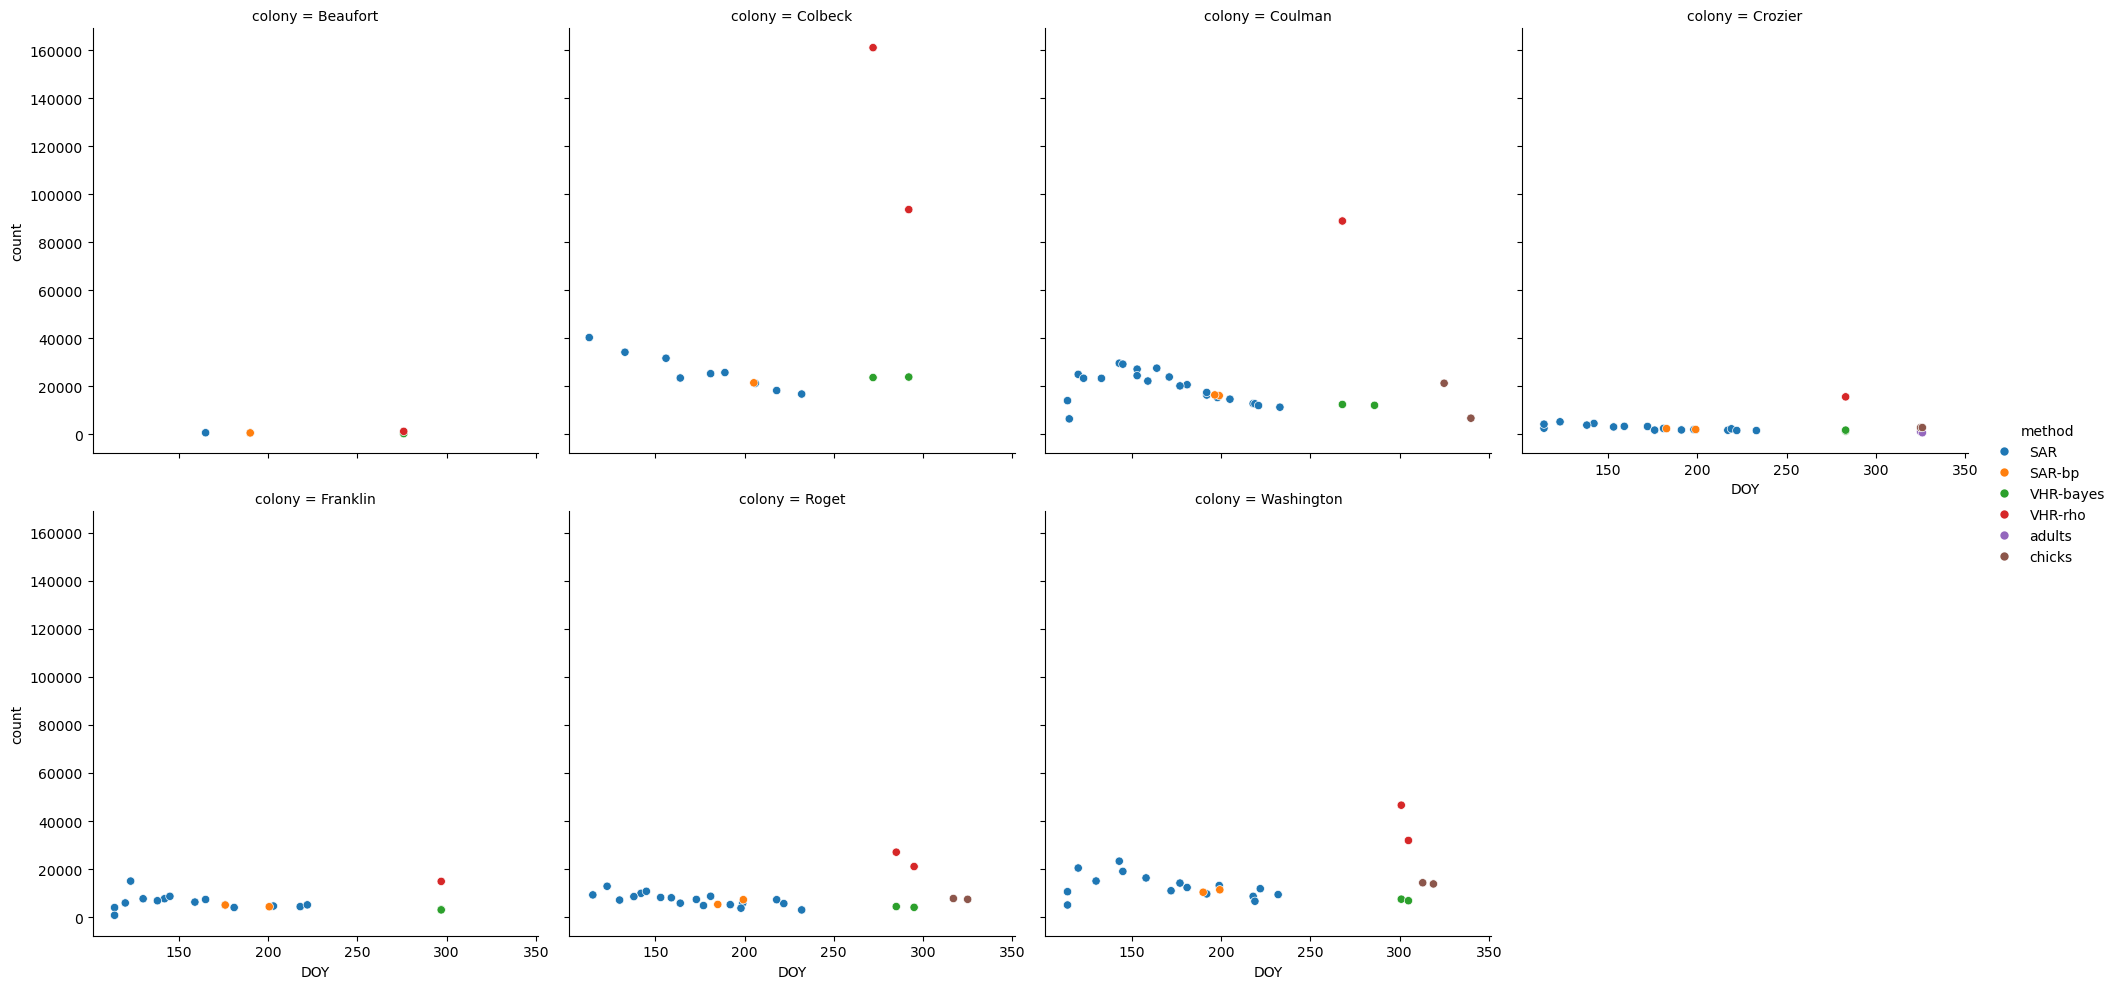

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creates a row of separate subplots for each colony
sns.relplot(
    data=df_RossSea, 
    x='DOY', 
    y='count', 
    col='colony',   # Separate subplots by colony
    hue='method',   # Distinct colors for each method
    kind='scatter',  # Can change to 'line' if needed
    col_wrap=4)

plt.show()

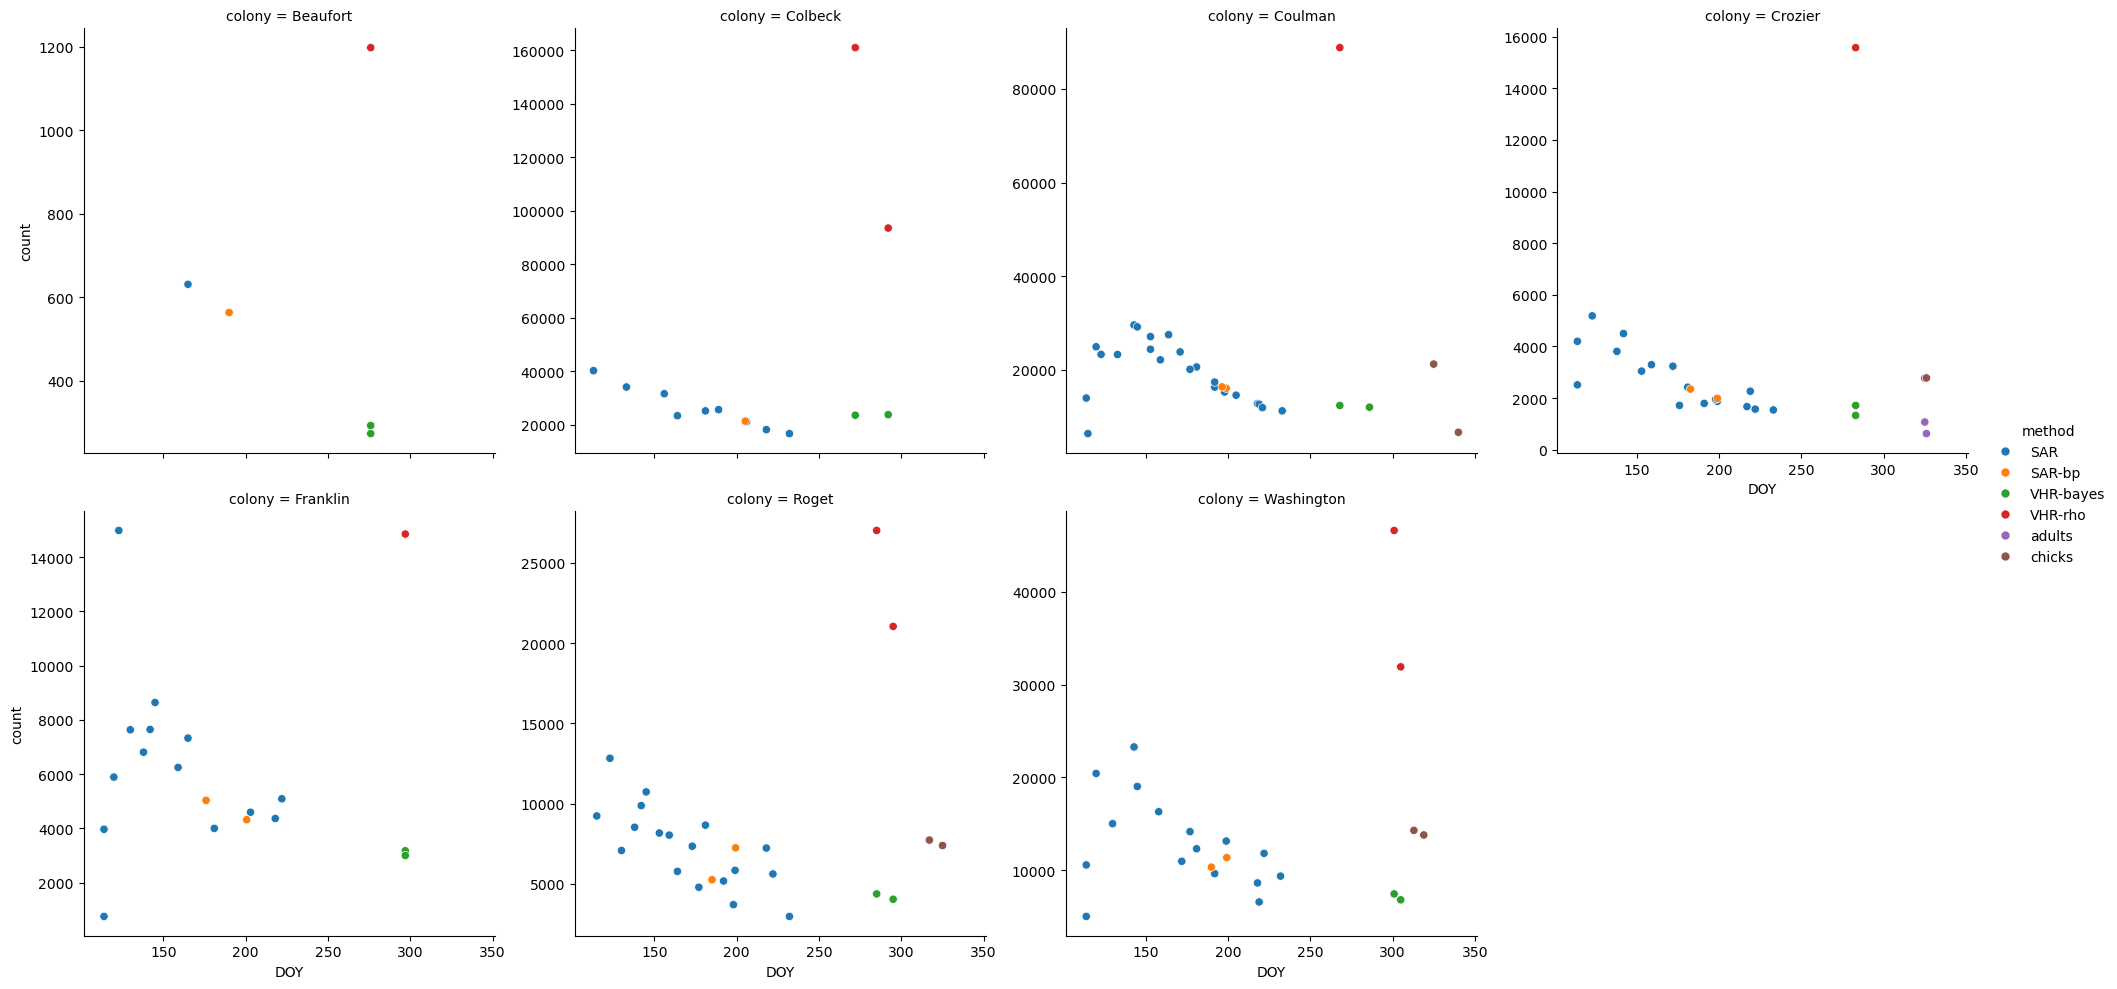

In [15]:
# Recreating above plot with unique yaxes so we can better see the data range 

# Creates a row of separate subplots for each colony
sns.relplot(
    data=df_RossSea, 
    x='DOY', 
    y='count', 
    col='colony',   # Separate subplots by colony
    hue='method',   # Distinct colors for each method
    kind='scatter',  # Can change to 'line' if needed
    col_wrap=4, 
    facet_kws=dict(sharey=False))

plt.show()

## We want to exclude the VHR-rho data 

These data are those that used the huddle areas derived from high resolution optical imagery along with the Winterl et al. 2024 windchill model and they produce non sensical data.   

This is becuase the rho values vary between 4.275 and 6.059 birds per m2, which when individual penguins are included on the ice, not huddled, creates a vast overestimation about how many birds there are in each meter. This makes sense when considering densley aggregated huddles, but our VHR analysis also captures more loosely aggregated birds 



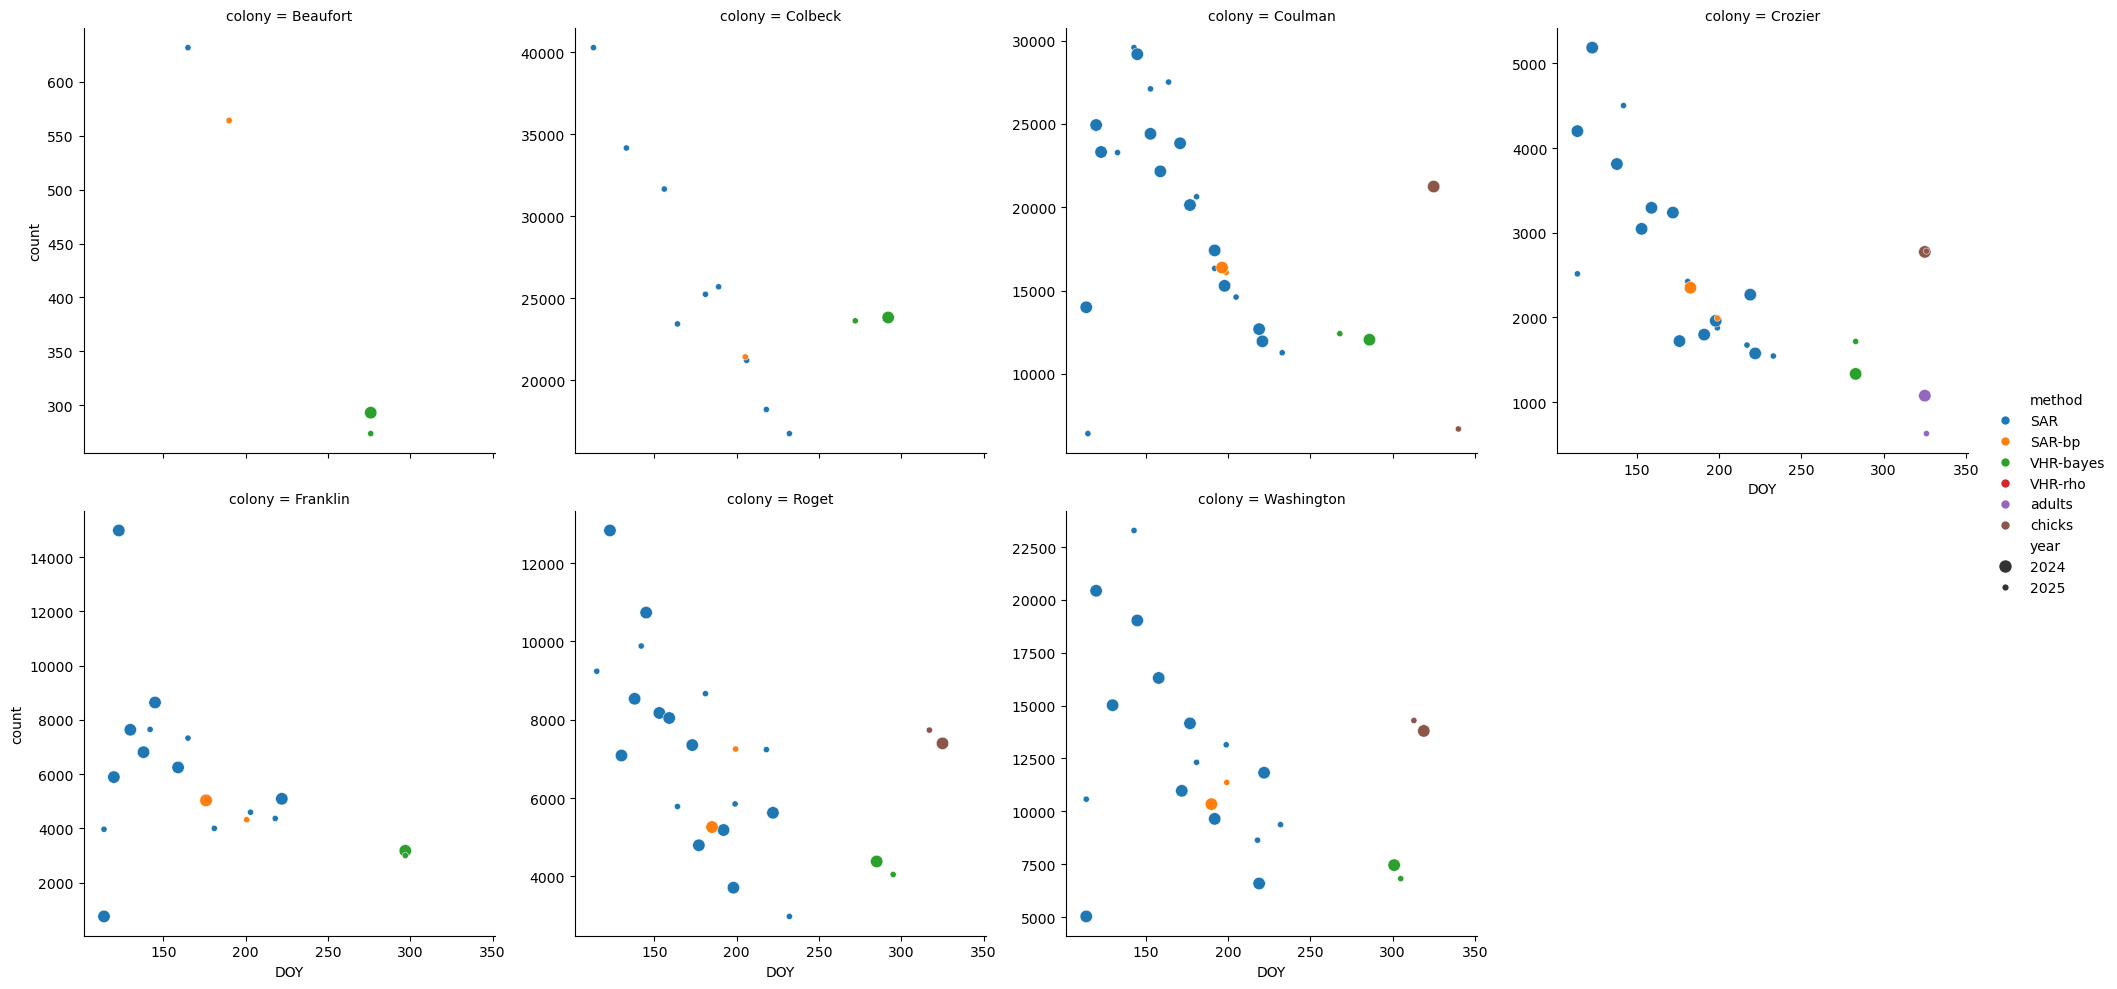

In [16]:
# Exclude a level from method 

filtered_df_RS = df_RossSea[df_RossSea["method"] != "VHR-rho"]

# Creates a row of separate subplots for each colony
sns.relplot(
    data=filtered_df_RS, 
    x='DOY', 
    y='count', 
    col='colony',   # Separate subplots by colony
    hue='method',   # Distinct colors for each method
    kind='scatter',  # Can change to 'line' if needed
    col_wrap=4, 
    size = 'year', 
    sizes = (20, 80),
    facet_kws=dict(sharey=False))

plt.show()

## Create invidual plots for each year 

Beaufort and Colbeck only have 2025 data 


In [17]:
# Exclude a level from method, and create new dataframe with data from each year 

filtered_df_RS = df_RossSea[df_RossSea["method"] != "VHR-rho"]
filtered_df_RS24 = filtered_df_RS[filtered_df_RS["year"] != 2025]
filtered_df_RS25 = filtered_df_RS[filtered_df_RS["year"] != 2024]


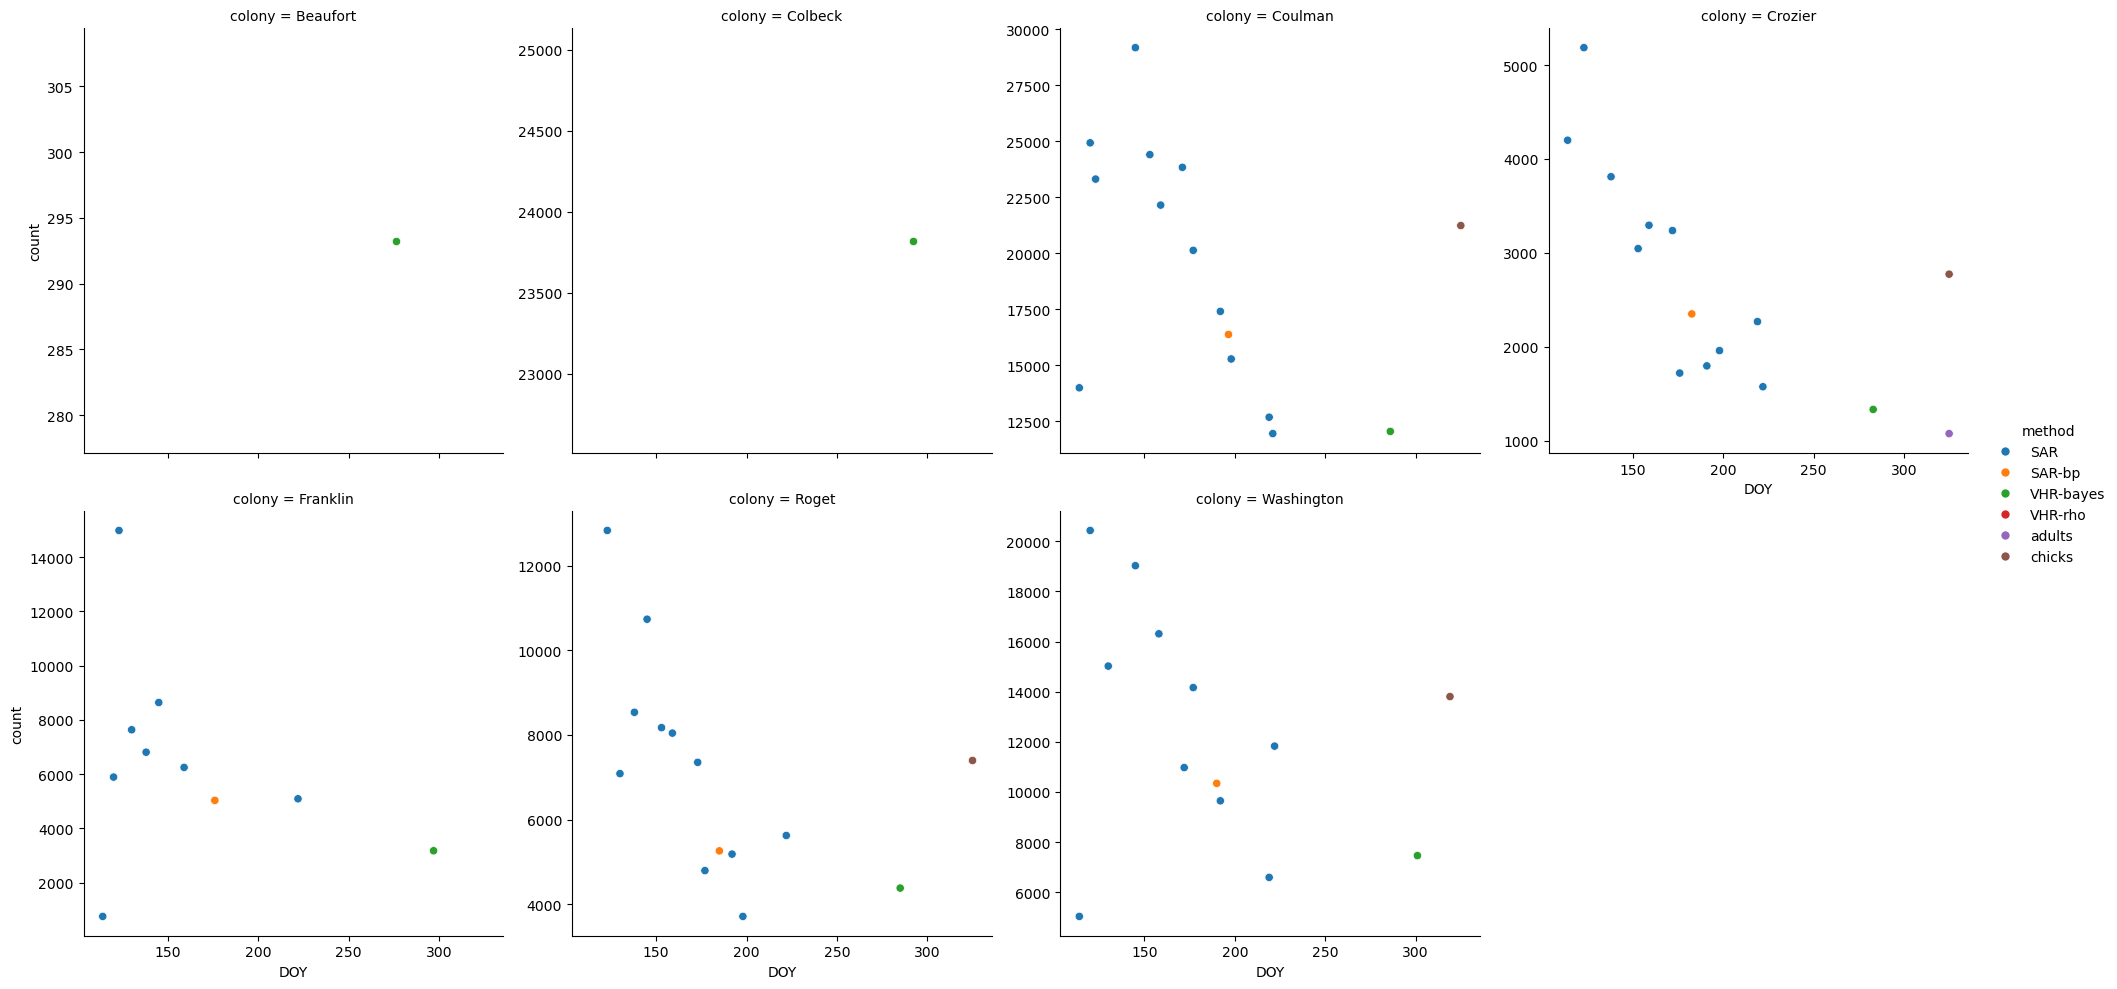

In [18]:
#  ONLY 2024 DATA 
# Creates a row of separate subplots for each colony
ax = sns.relplot(
    data=filtered_df_RS24, 
    x='DOY', 
    y='count', 
    col='colony',   # Separate subplots by colony
    hue='method',   # Distinct colors for each method
    kind='scatter',  # Can change to 'line' if needed
    col_wrap=4, 
    #size = 'year', 
    #sizes = (20, 80),
    facet_kws=dict(sharey=False), 
    )

plt.show()


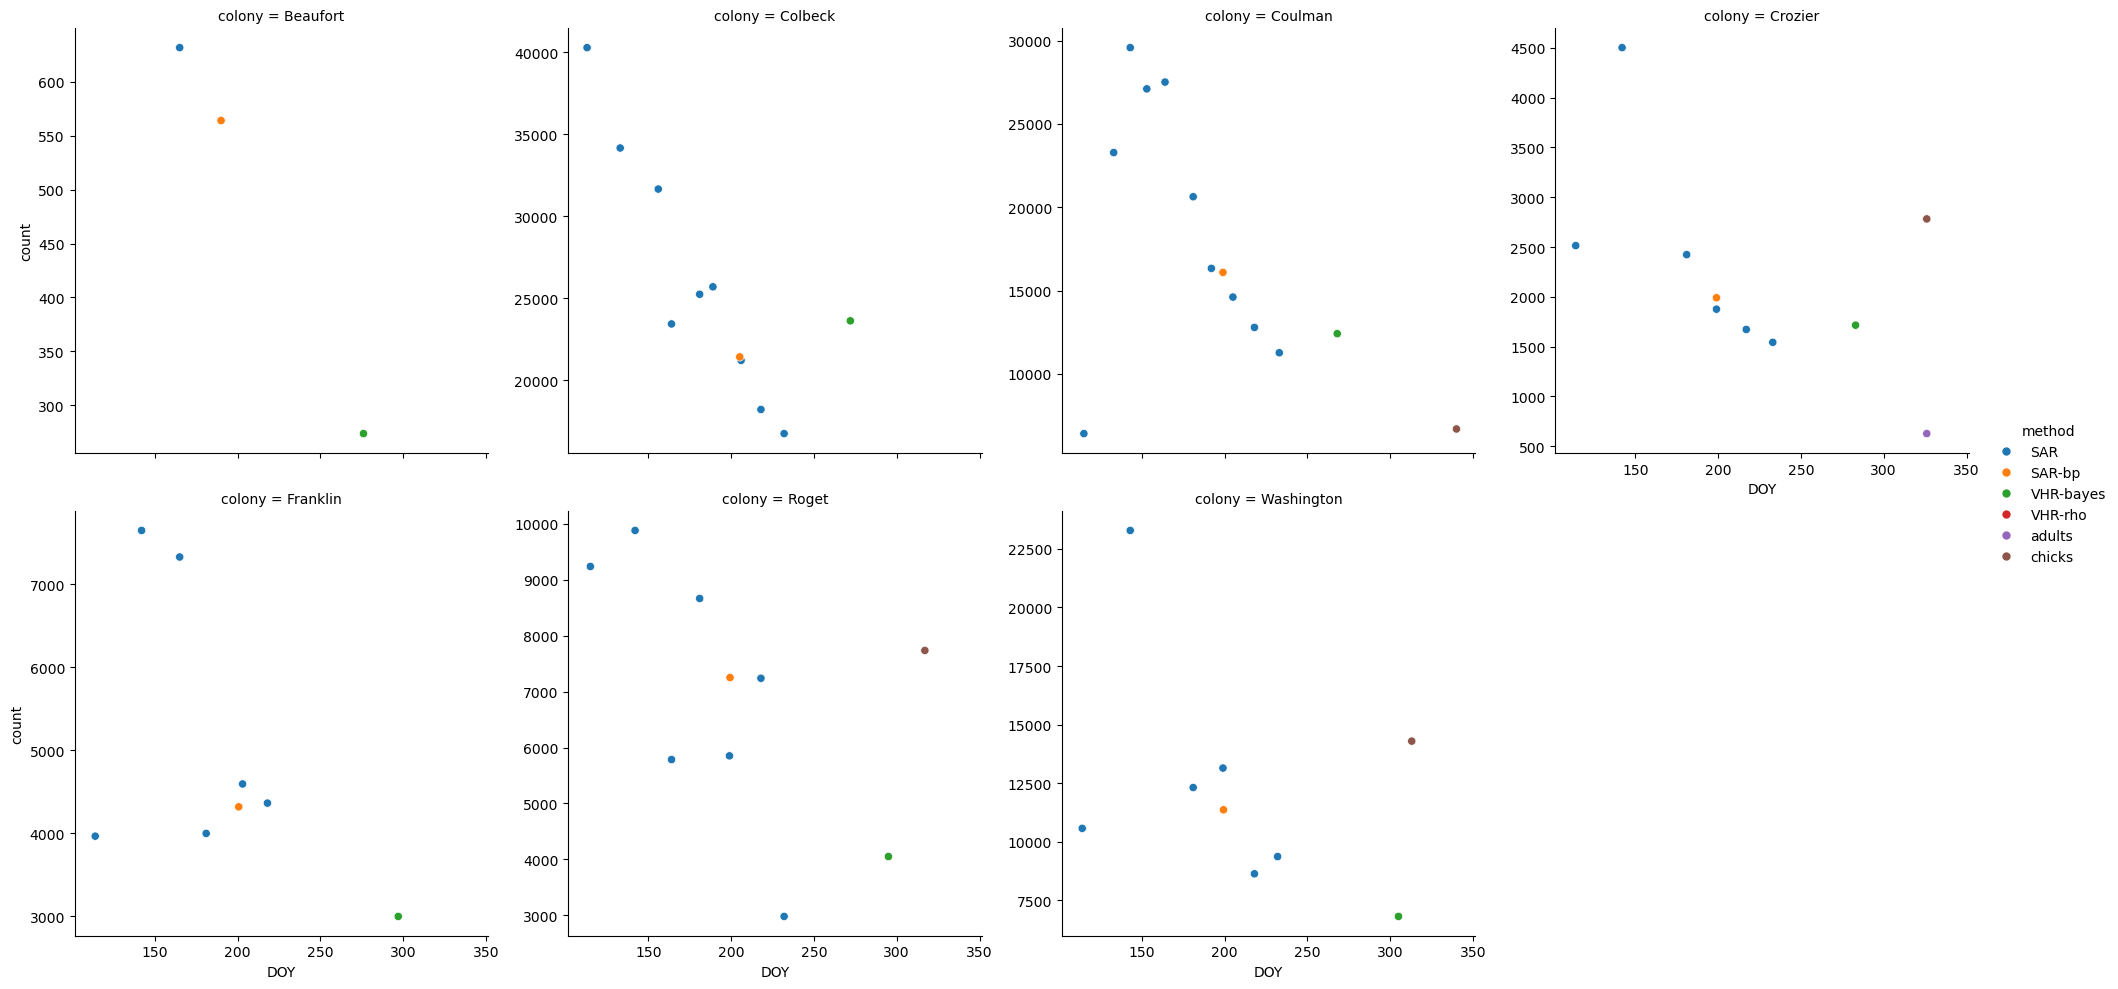

In [19]:
#  ONLY 2025 DATA 
# Creates a row of separate subplots for each colony
ax = sns.relplot(
    data=filtered_df_RS25, 
    x='DOY', 
    y='count', 
    col='colony',   # Separate subplots by colony
    hue='method',   # Distinct colors for each method
    kind='scatter',  # Can change to 'line' if needed
    col_wrap=4, 
    #size = 'year', 
    #sizes = (20, 80),
    facet_kws=dict(sharey=False), 
    )

plt.show()

## Try a line plot

I would like the SAR-individuals as lines but the others as points, as there are just one of each. 


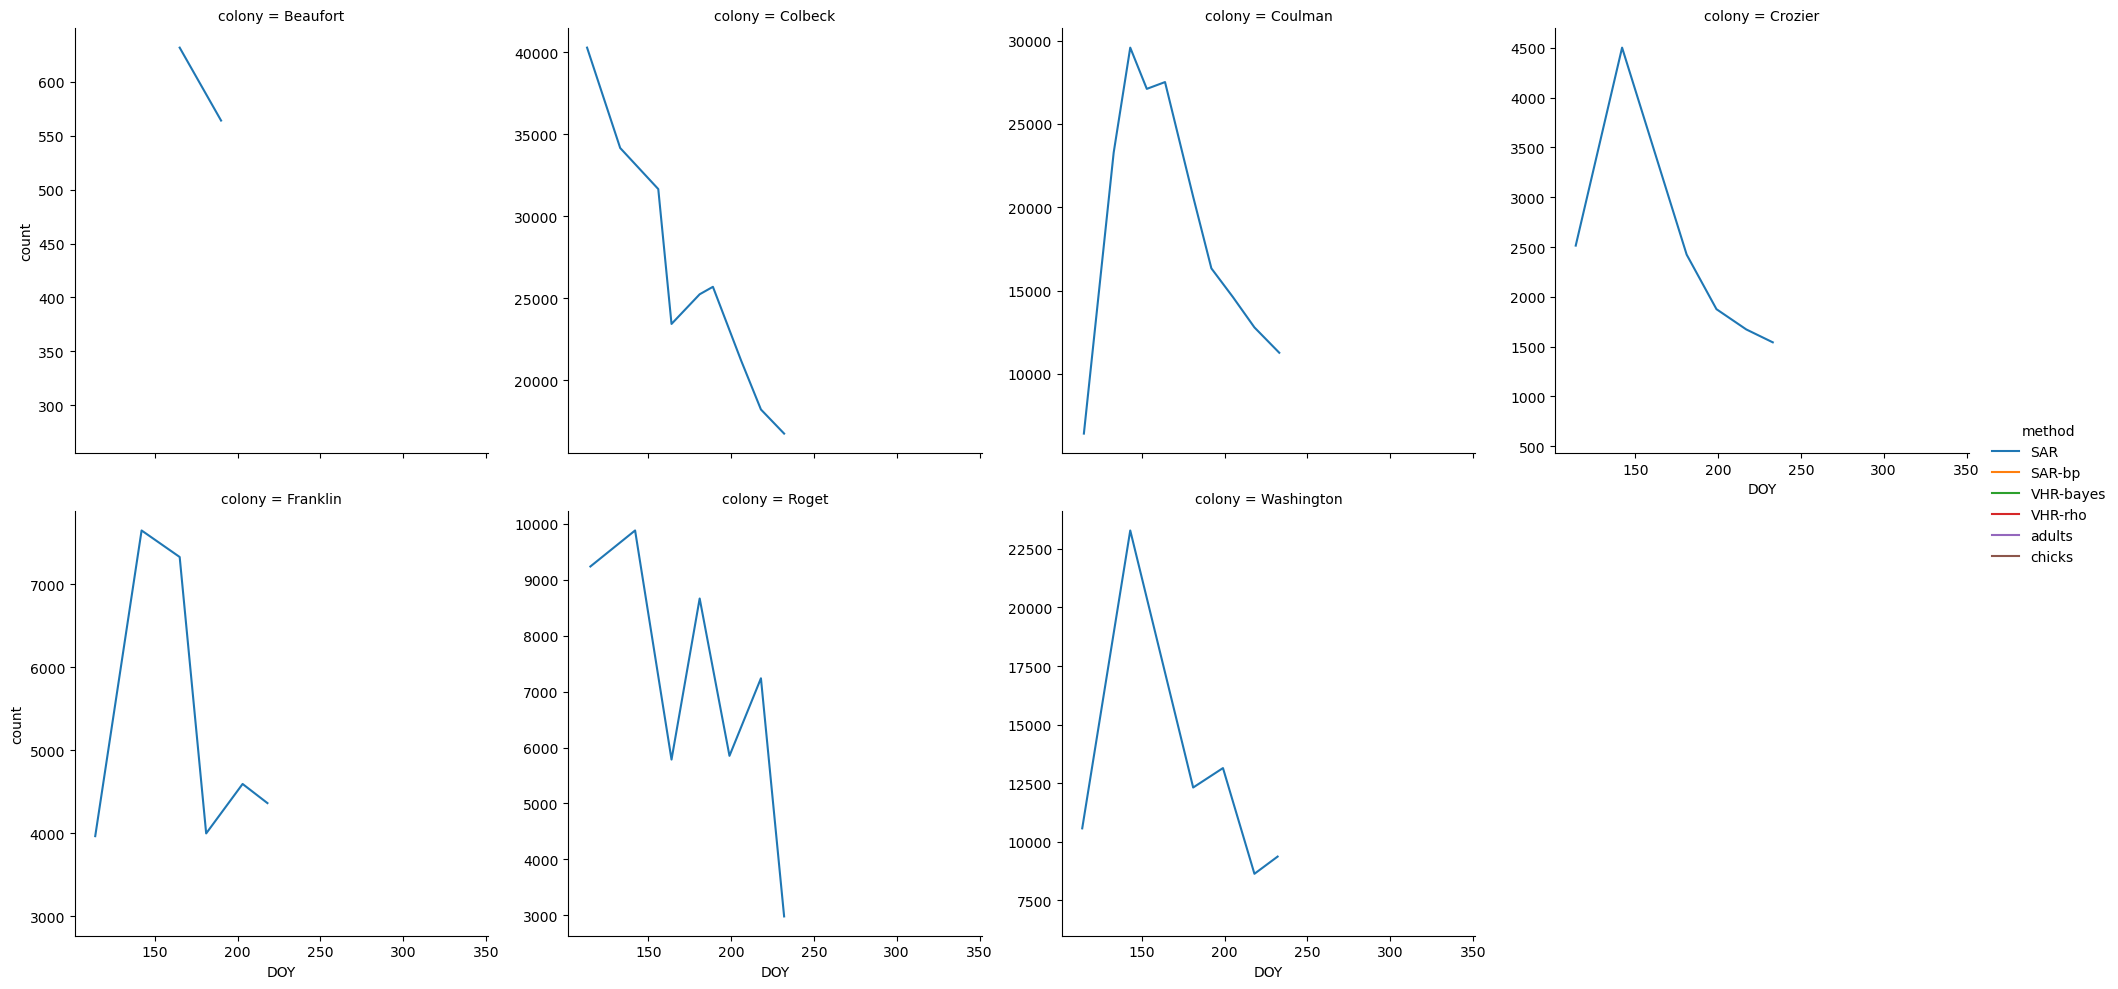

In [20]:
#  ONLY 2025 DATA 
# Creates a row of separate subplots for each colony
ax = sns.relplot(
    data=filtered_df_RS25, 
    x='DOY', 
    y='count', 
    col='colony',   # Separate subplots by colony
    hue='method',   # Distinct colors for each method
    kind='line',  # Can change to 'line' if needed
   # kind='scatter',
    col_wrap=4, 
    #size = 'year', 
    #sizes = (20, 80),
    facet_kws=dict(sharey=False), 
    )

plt.show()

### I think to achieve this it needs to be done using a different tool, as cannot use two different point types in seaborn package


## Let's try with matplotlib 

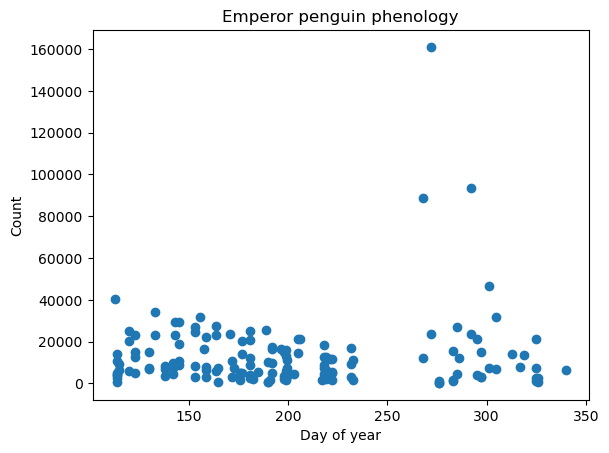

In [21]:

#test simple plot 

fig, ax = plt.subplots()
ax.scatter(df_RossSea["DOY"], df_RossSea["count"])
ax.set(xlabel='Day of year',
       ylabel='Count',
       title='Emperor penguin phenology')

plt.show()



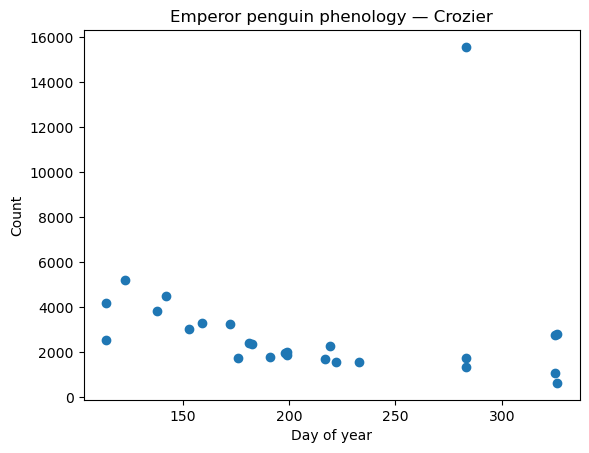

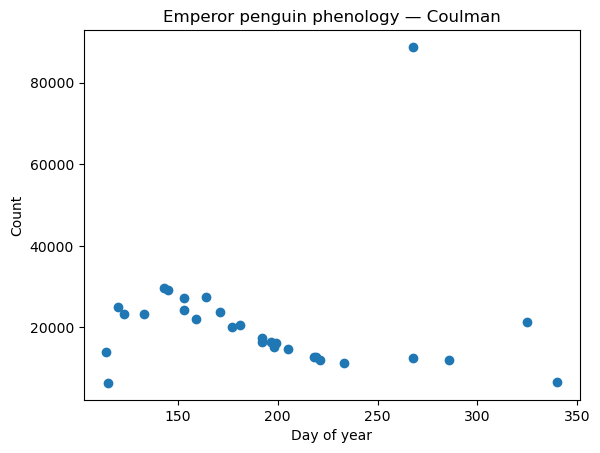

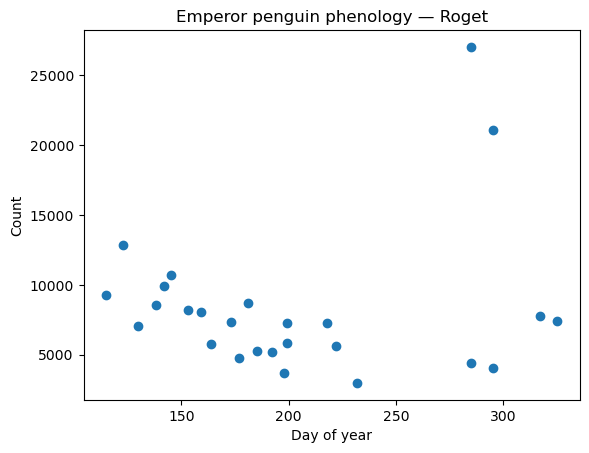

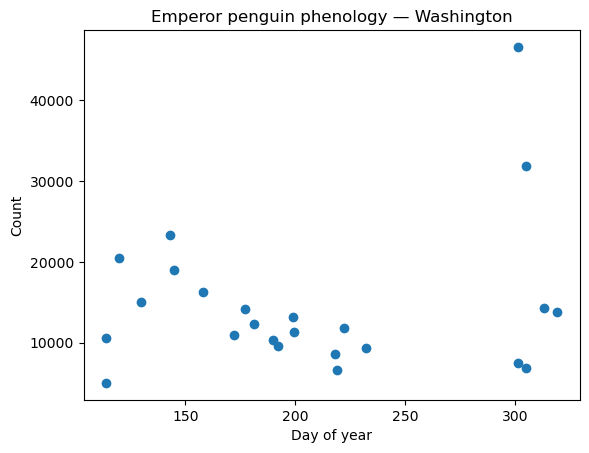

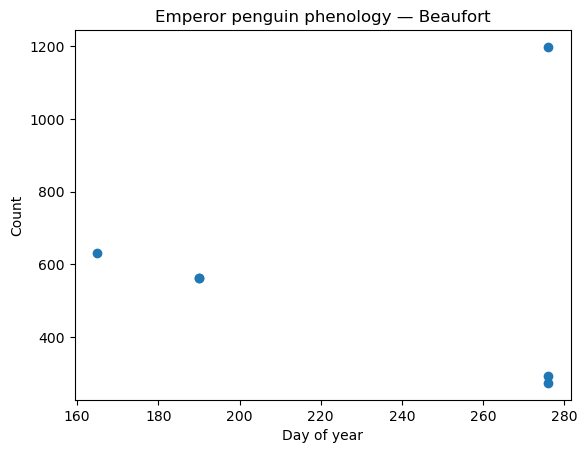

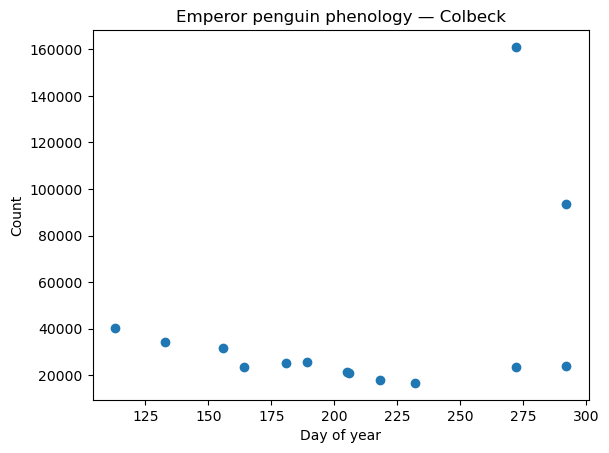

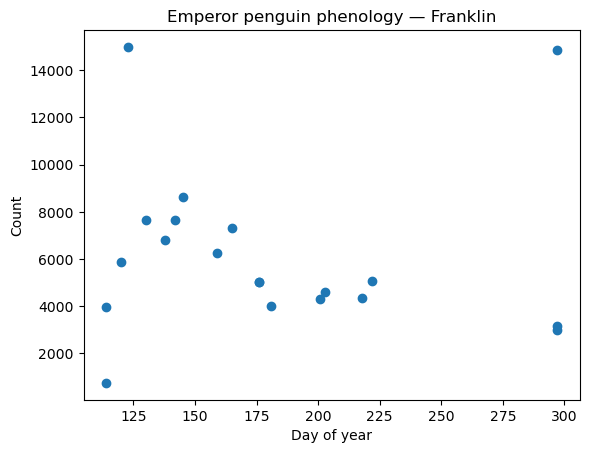

In [22]:
#Ok got that to run, basics. 

#Now I want to create subplots for each colony as I had done with the other package 

for colony in df_RossSea["colony"].unique():
    df_colony = df_RossSea[df_RossSea["colony"] == colony]
    fig, ax = plt.subplots()
    
    ax.scatter(
        df_colony["DOY"],
        df_colony["count"]
    )
    
    ax.set(
        xlabel="Day of year",
        ylabel="Count",
        title=f"Emperor penguin phenology — {colony}"
    )
    
    plt.show()

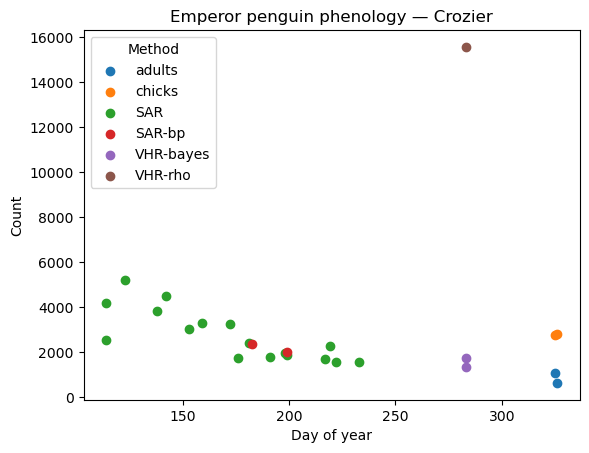

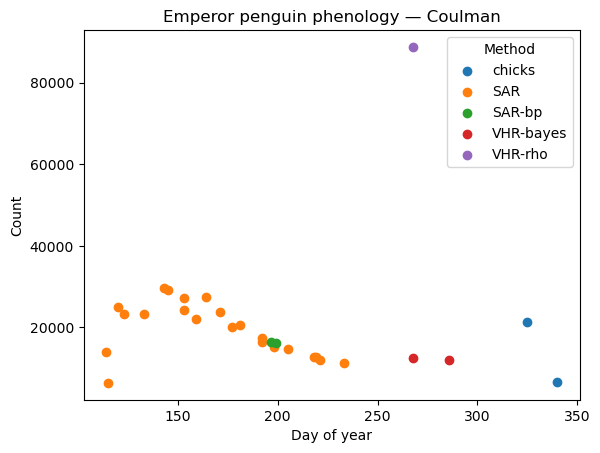

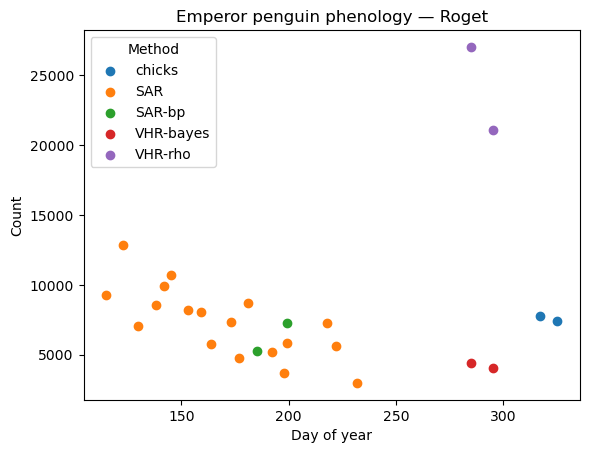

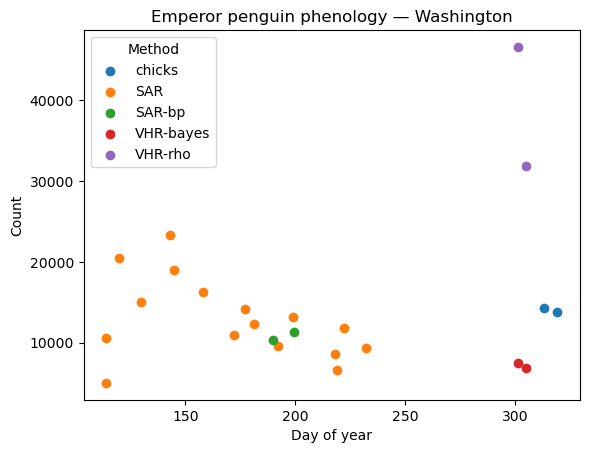

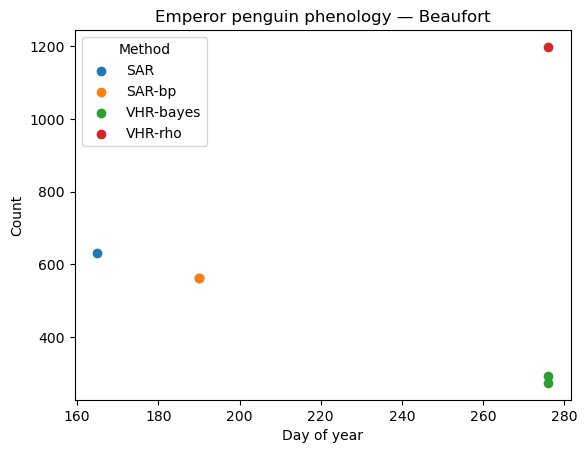

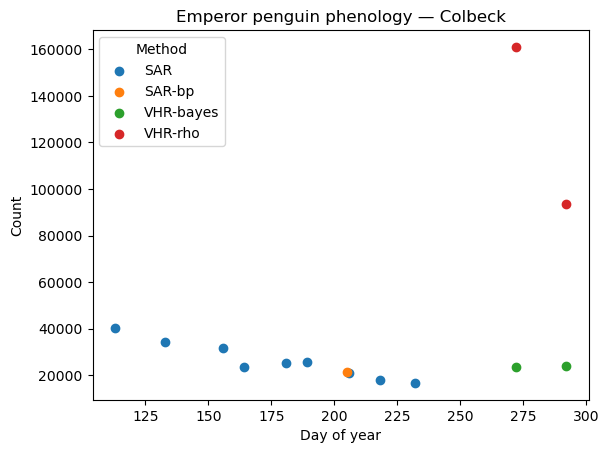

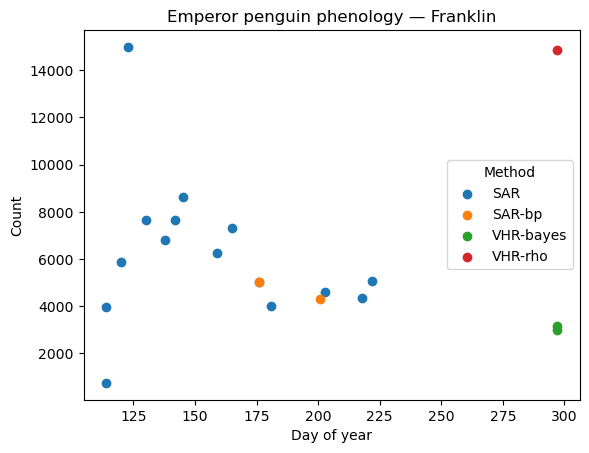

In [23]:

for colony in df_RossSea["colony"].unique():
    
    df_colony = df_RossSea[df_RossSea["colony"] == colony]
    
    fig, ax = plt.subplots()
    
    for method in df_colony["method"].unique():
        
        df_method = df_colony[df_colony["method"] == method]

        ax.scatter(
            df_method["DOY"],
            df_method["count"],
            label=method
        )
    
    ax.set(
        xlabel="Day of year",
        ylabel="Count",
        title=f"Emperor penguin phenology — {colony}"
    )
    
    ax.legend(title="Method")
    
    plt.show()

## Let's make a multi panel plot 



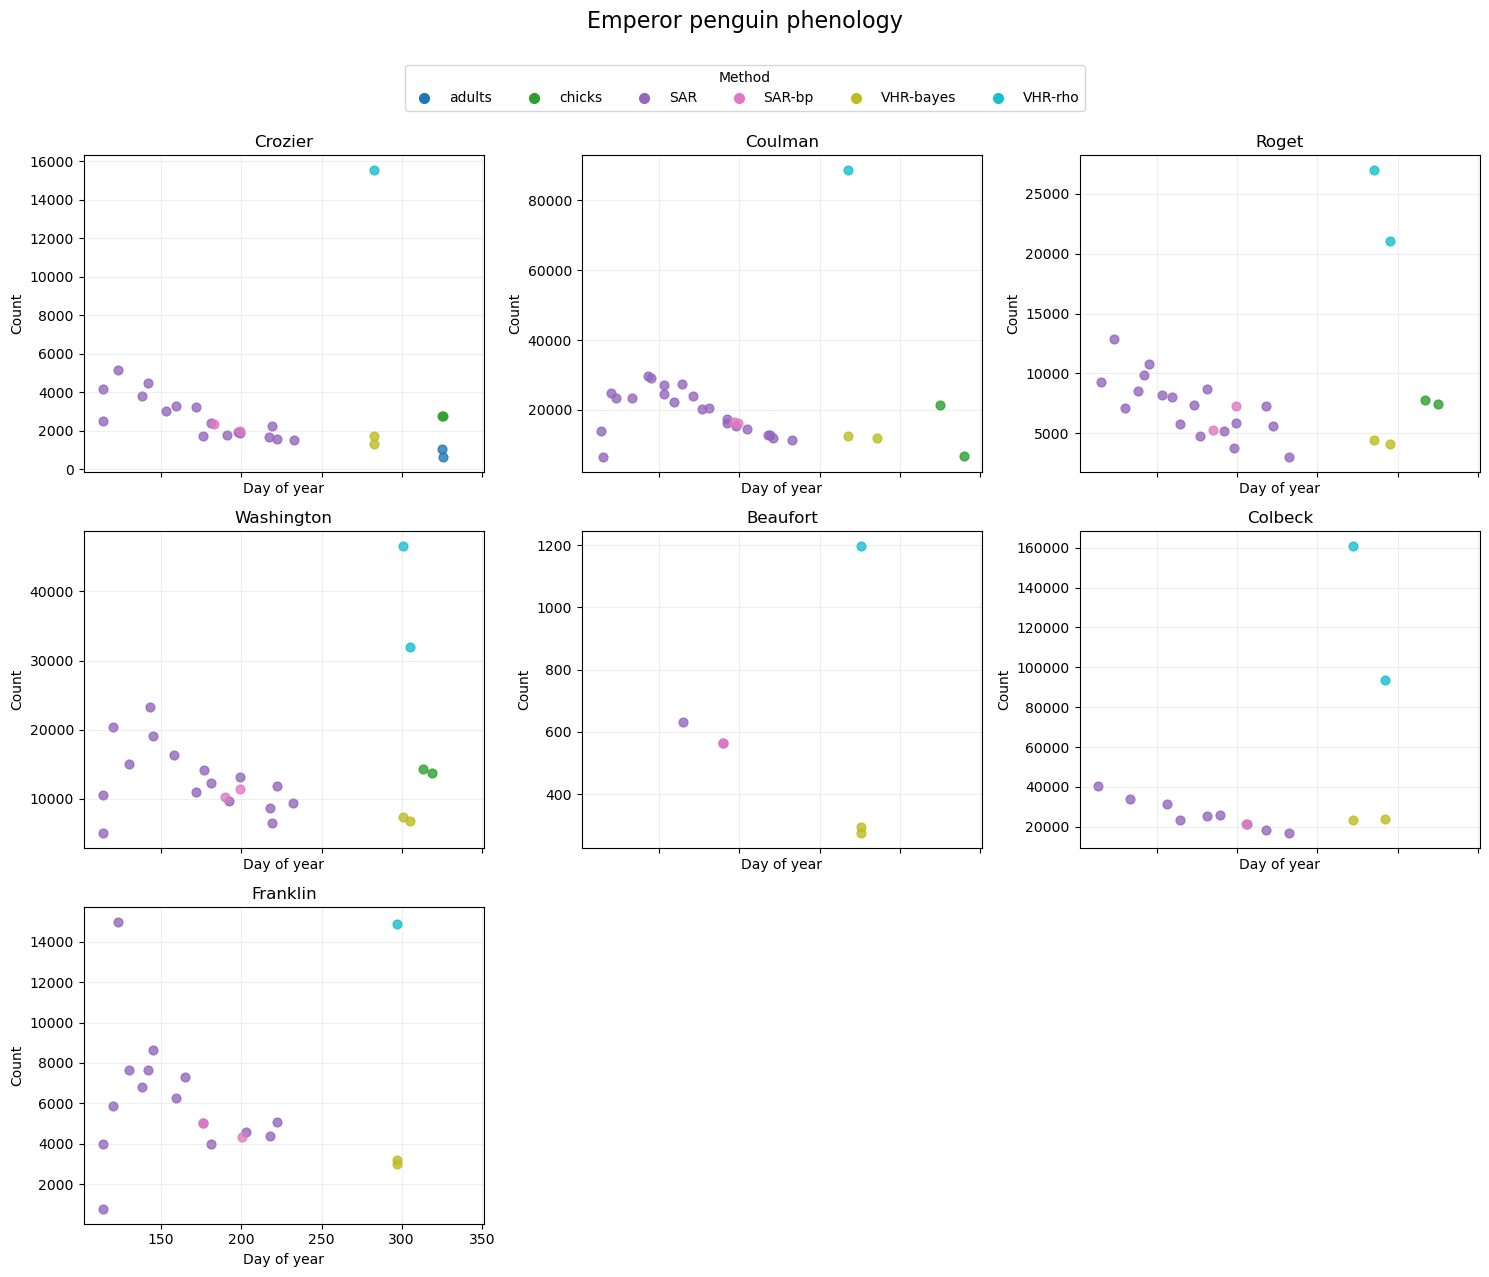

In [24]:
## Changing to a multi panel plot 

# Get categories
colonies = df_RossSea["colony"].dropna().unique()
methods = df_RossSea["method"].dropna().unique()

# panel layout
n_cols = 3
n_rows = int(np.ceil(len(colonies) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows),
    sharex=True,
    sharey=False
)

# Flatten axes so they are easy to loop through
axes = np.atleast_1d(axes).flatten()

# Assign one colour to each method
colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
method_colors = dict(zip(methods, colors))

# Plot each colony in its own panel
for ax, colony in zip(axes, colonies):

    df_colony = df_RossSea[df_RossSea["colony"] == colony]

    for method in methods:

        df_method = df_colony[df_colony["method"] == method]

        ax.scatter(
            df_method["DOY"],
            df_method["count"],
            color=method_colors[method],
            label=method,
            s=40,
            alpha=0.8
        )

    ax.set_title(colony)
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.2)

# Remove any unused panels
for ax in axes[len(colonies):]:
    ax.remove()

# Create one shared legend for the whole figure
handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        color=method_colors[method],
        label=method,
        markersize=7
    )
    for method in methods
]

fig.legend(
    handles=handles,
    title="Method",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(methods)
)

fig.suptitle(
    "Emperor penguin phenology",
    fontsize=16,
    y=1.06
)

plt.tight_layout()
plt.show()

## Let's test the two data types scatter and line 

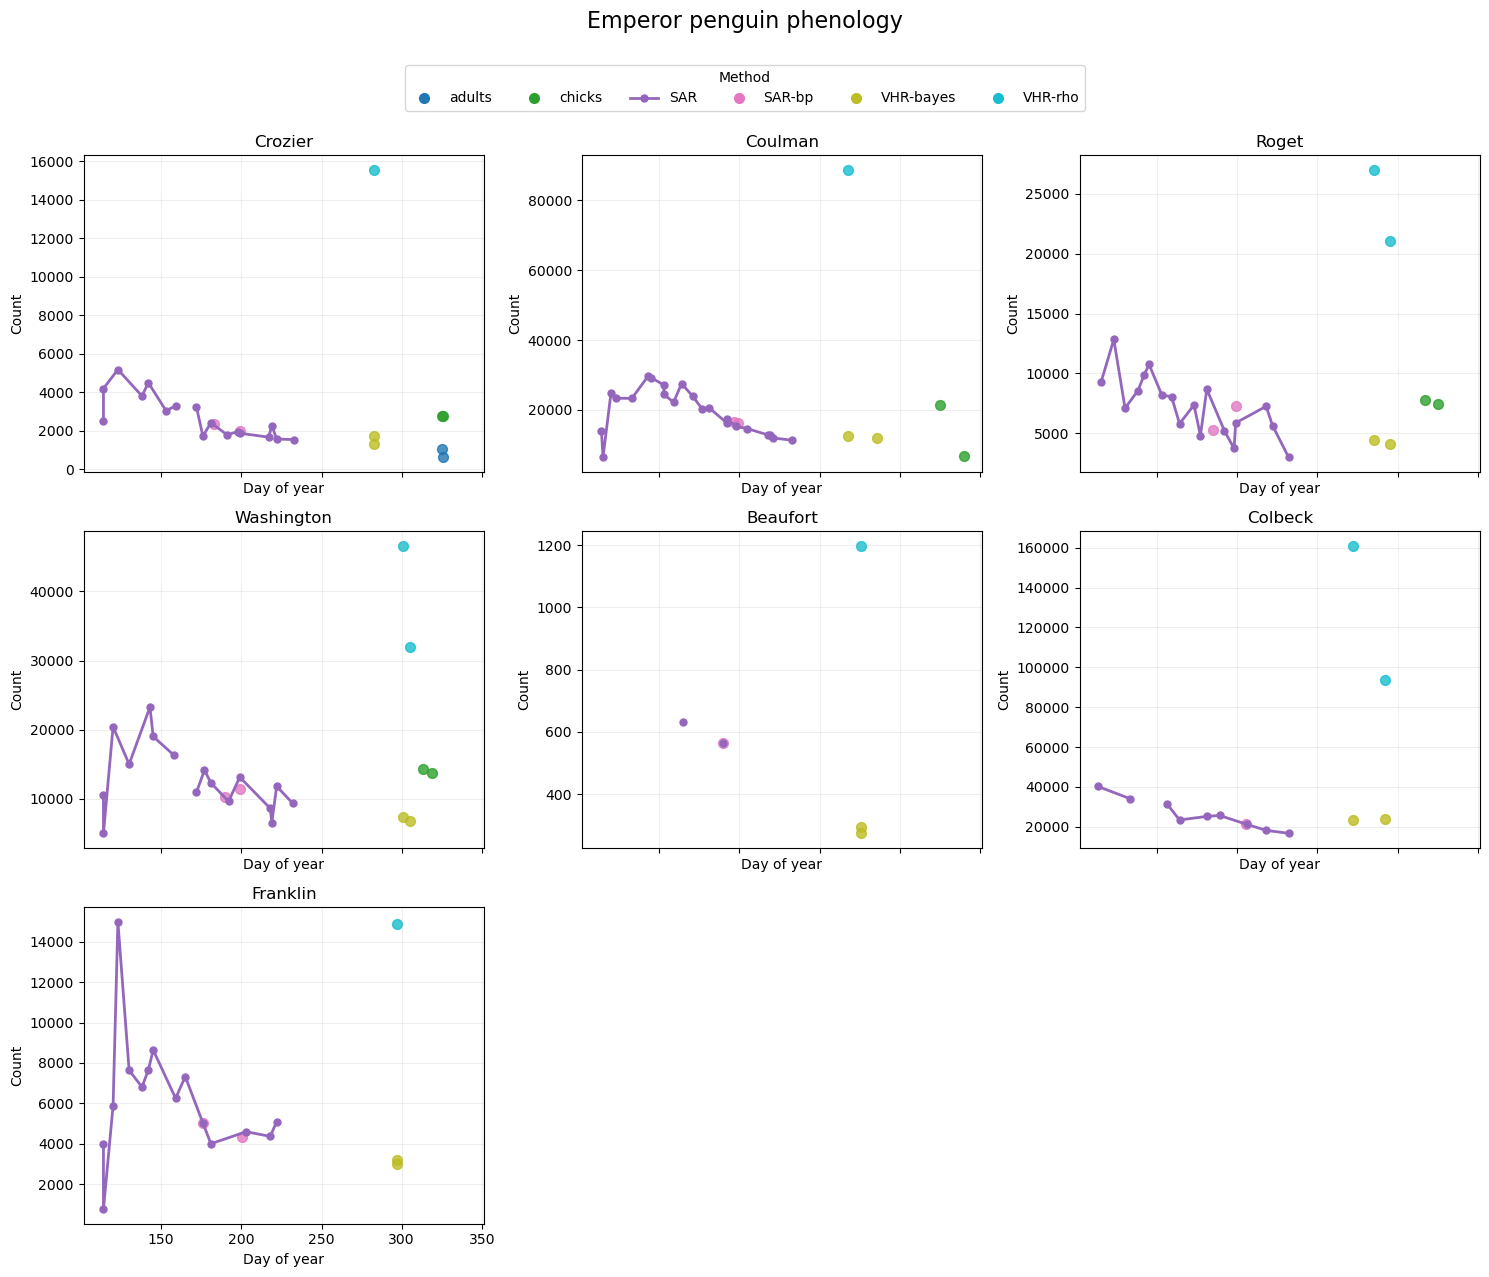

In [25]:
# Get categories
colonies = df_RossSea["colony"].dropna().unique()
methods = df_RossSea["method"].dropna().unique()

# Work out panel layout
n_cols = 3
n_rows = int(np.ceil(len(colonies) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows),
    sharex=True,
    sharey=False
)

# Flatten axes so they are easy to loop through
axes = np.atleast_1d(axes).flatten()

# Assign one colour to each method
colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
method_colors = dict(zip(methods, colors))

# Plot each colony in its own panel
for ax, colony in zip(axes, colonies):

    df_colony = df_RossSea[df_RossSea["colony"] == colony]

    for method in methods:

        df_method = df_colony[df_colony["method"] == method].copy()

        # SAR = line
        if method == "SAR":

            # Sort by day of year so the line connects points correctly
            df_method = df_method.sort_values("DOY")

            ax.plot(
                df_method["DOY"],
                df_method["count"],
                color=method_colors[method],
                linewidth=2,
                marker="o",
                markersize=5,
                label=method
            )

        # All other methods = scatter
        else:

            ax.scatter(
                df_method["DOY"],
                df_method["count"],
                color=method_colors[method],
                s=50,
                alpha=0.8,
                label=method
            )

    ax.set_title(colony)
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.2)

# Remove unused panels
for ax in axes[len(colonies):]:
    ax.remove()

# One shared legend
handles = []

for method in methods:

    if method == "SAR":

        handle = plt.Line2D(
            [0], [0],
            color=method_colors[method],
            linewidth=2,
            marker="o",
            markersize=5,
            label=method
        )

    else:

        handle = plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            color=method_colors[method],
            markersize=7,
            label=method
        )

    handles.append(handle)

fig.legend(
    handles=handles,
    title="Method",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(methods)
)

fig.suptitle(
    "Emperor penguin phenology",
    fontsize=16,
    y=1.06
)

plt.tight_layout()
plt.show()

## Let's present 2024 and 2025 differently as below

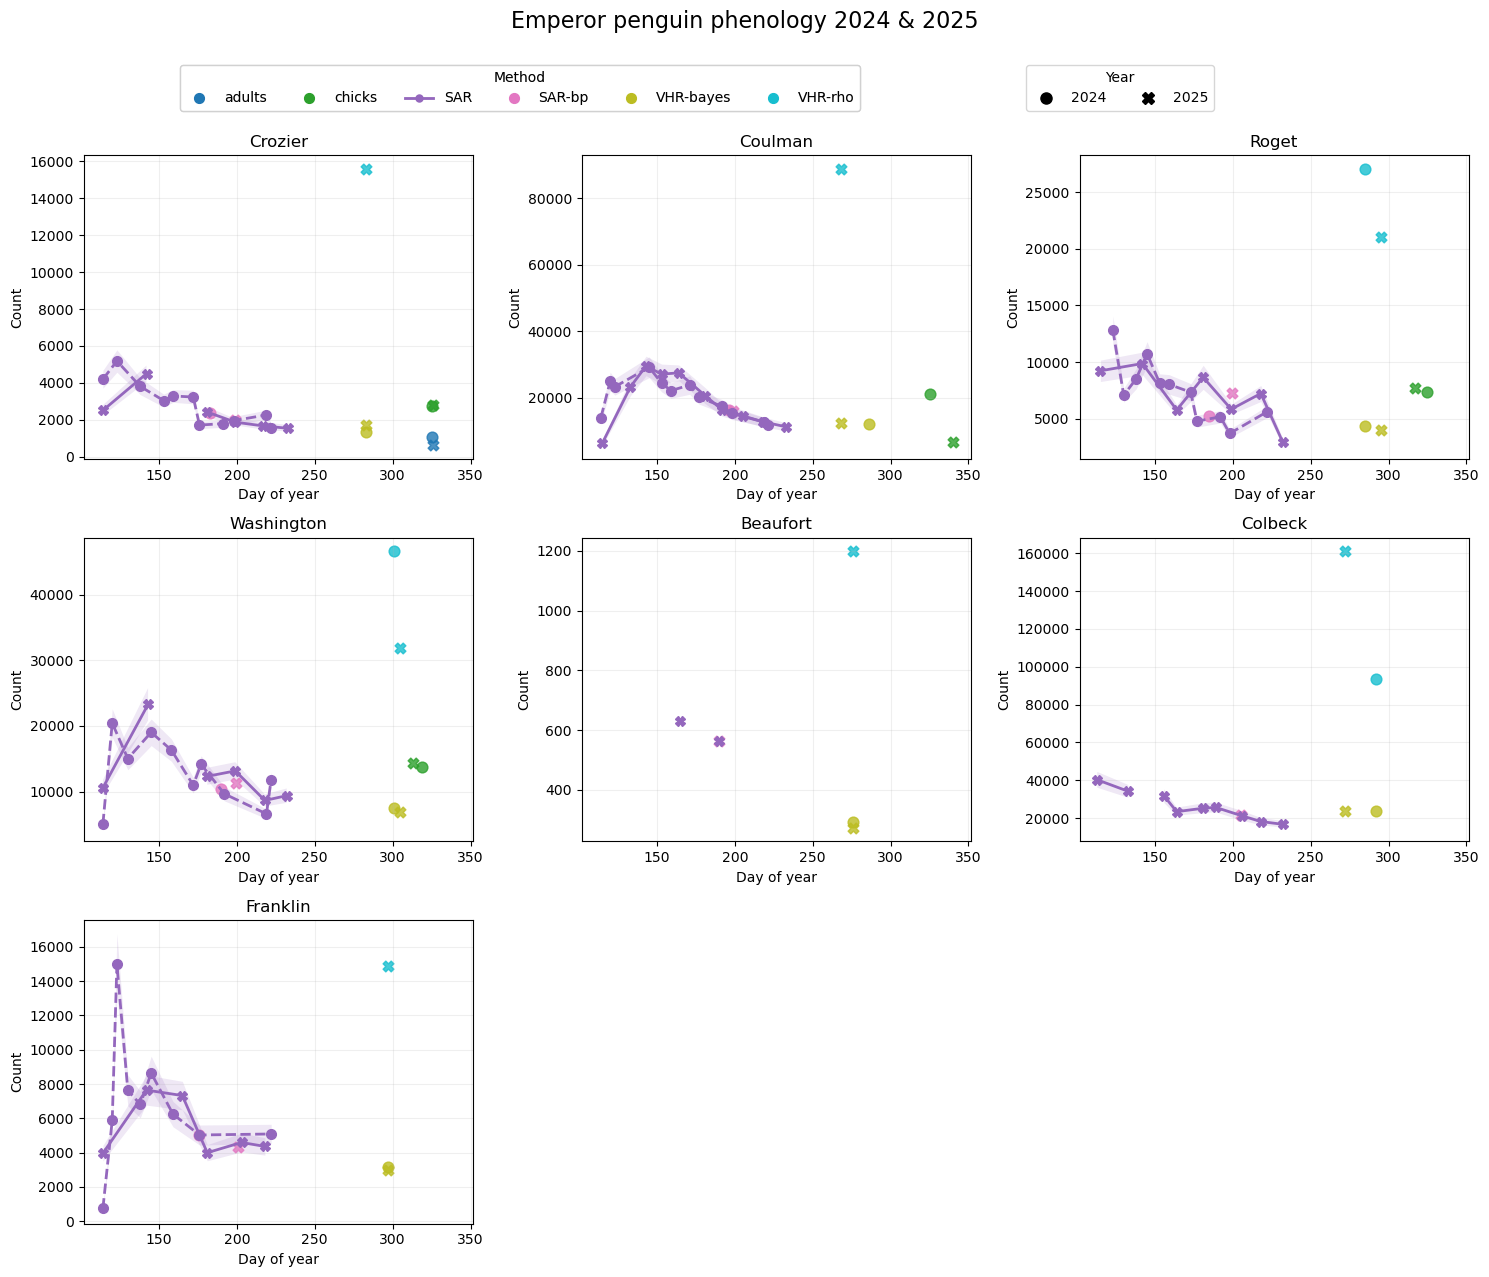

In [26]:
# Get categories
colonies = df_RossSea["colony"].dropna().unique()
methods = df_RossSea["method"].dropna().unique()

# Work out panel layout
n_cols = 3
n_rows = int(np.ceil(len(colonies) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows),
    sharex=True,
    sharey=False
)

years = sorted(df_RossSea["year"].dropna().unique())

year_markers = {
    2024: "o",
    2025: "X"
}

year_linestyles = {
    2024: "--",
    2025: "-"
}

# Flatten axes so they are easy to loop through
axes = np.atleast_1d(axes).flatten()

# Assign one colour to each method
colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
method_colors = dict(zip(methods, colors))

# Plot each colony in its own panel
# Plot each colony in its own panel
for ax, colony in zip(axes, colonies):

    df_colony = df_RossSea[df_RossSea["colony"] == colony]

    for method in methods:

        for year in years:

            df_method_year = df_colony[
                (df_colony["method"] == method) &
                (df_colony["year"] == year)
            ].copy()

            # SAR = line
            if method == "SAR":

                # Sort by day of year so the line connects points correctly
                df_method_year = df_method_year.sort_values("DOY")

                #adding in uncertainty ribbons
                ax.fill_between(
                    df_method_year["DOY"],
                    df_method_year["count"] - df_method_year["count_se"],
                    df_method_year["count"] + df_method_year["count_se"],
                    color=method_colors[method],
                    alpha=0.15,
                    linewidth=0
                )
                #sar trajectory
                ax.plot(
                    df_method_year["DOY"],
                    df_method_year["count"],
                    color=method_colors[method],
                    linewidth=2,
                     linestyle=year_linestyles[year],
                    marker=year_markers[year],
                    markersize=7,
                    label=f"{method} {year}"
                )

            # All other methods = scatter
            else:

                ax.scatter(
                    df_method_year["DOY"],
                    df_method_year["count"],
                    color=method_colors[method],
                    marker=year_markers[year],
                    s=60,
                    alpha=0.8,
                    label=f"{method} {year}"
                )

    ax.set_title(colony)
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.2)
    ax.tick_params(axis="x", labelbottom=True)

# Remove unused panels
for ax in axes[len(colonies):]:
    ax.remove()

# One shared legend
handles = []

for method in methods:

    if method == "SAR":

        handle = plt.Line2D(
            [0], [0],
            color=method_colors[method],
            linewidth=2,
            marker="o",
            markersize=5,
            label=method
        )

    else:

        handle = plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            color=method_colors[method],
            markersize=7,
            label=method
        )

    handles.append(handle)


# Method legend — colour
method_handles = []

for method in methods:

    if method == "SAR":

        handle = plt.Line2D(
            [0], [0],
            color=method_colors[method],
            linewidth=2,
            marker="o",
            markersize=5,
            label=method
        )

    else:
        handle = plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            color=method_colors[method],
            markersize=7,
            label=method
        )

    method_handles.append(handle)


# Year legend — marker

year_handles = []

for year in years:

    handle = plt.Line2D(
        [0], [0],
        marker=year_markers[year],
        linestyle="",
        color="black",
        markersize=8,
        label=str(year)
    )

    year_handles.append(handle)

# Add legends
legend1 = fig.legend(
    handles=method_handles,
    title="Method",
    loc="upper center",
    bbox_to_anchor=(0.35, 1.02),
    ncol=len(methods)
)

legend2 = fig.legend(
    handles=year_handles,
    title="Year",
    loc="upper center",
    bbox_to_anchor=(0.75, 1.02),
    ncol=len(years)
)

fig.add_artist(legend1)

fig.suptitle(
    "Emperor penguin phenology 2024 & 2025",
    fontsize=16,
    y=1.06
)

plt.tight_layout()

plt.savefig(os.path.join(INPUTPATH, "Results/all_colonies_RS2425_alldata.png"),
           bbox_inches="tight", dpi=600)


plt.show()

## Ok brilliant - now we exclude VHR-rho as above 

Over time we will also create two plots for 2024 and 2025


In [27]:
# Exclude a level from method, and create new dataframe with data from each year 

filtered_df_RS = df_RossSea[df_RossSea["method"] != "VHR-rho"]
filtered_df_RS24 = filtered_df_RS[filtered_df_RS["year"] != 2025]
filtered_df_RS25 = filtered_df_RS[filtered_df_RS["year"] != 2024]

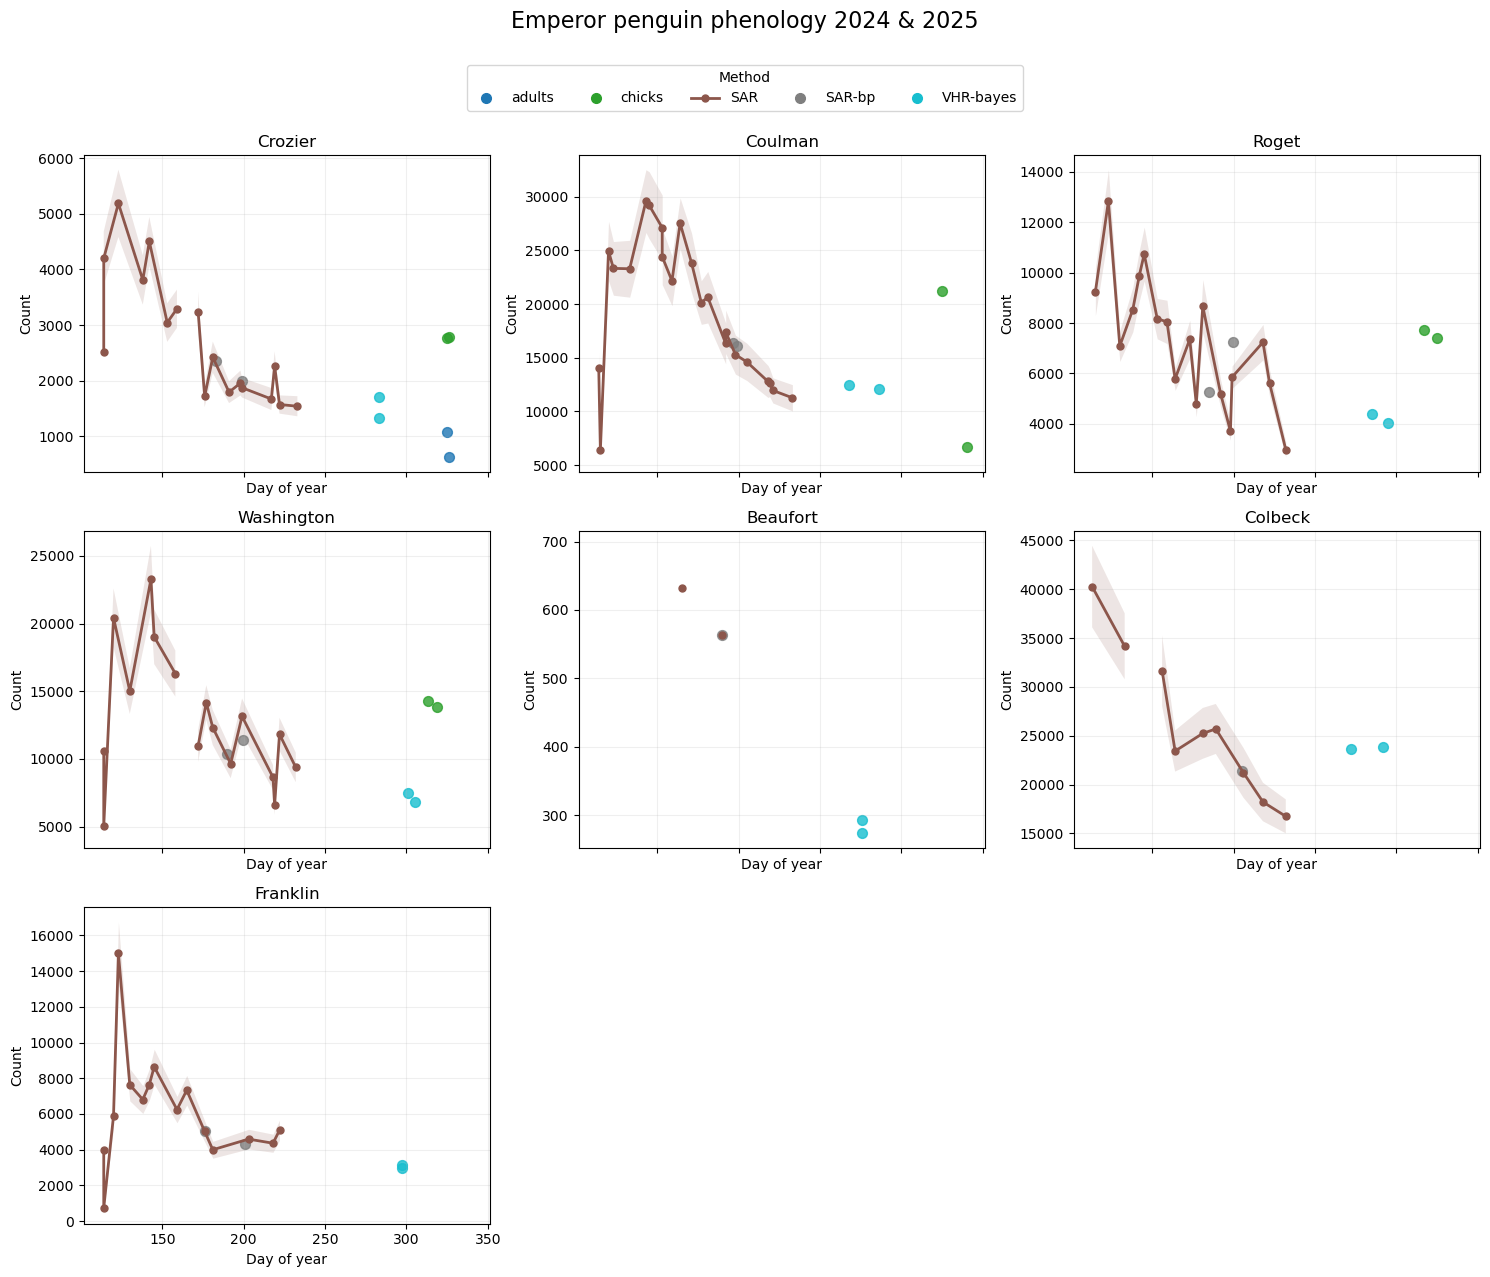

In [ ]:
# Get categories
colonies = filtered_df_RS["colony"].dropna().unique()
methods = filtered_df_RS["method"].dropna().unique()

# Work out panel layout
n_cols = 3
n_rows = int(np.ceil(len(colonies) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows),
    sharex=True,
    sharey=False
)


# Flatten axes so they are easy to loop through
axes = np.atleast_1d(axes).flatten()

# Assign one colour to each method
colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
method_colors = dict(zip(methods, colors))

# Plot each colony in its own panel
for ax, colony in zip(axes, colonies):

    df_colony = filtered_df_RS[filtered_df_RS["colony"] == colony]

    for method in methods:

        df_method = df_colony[df_colony["method"] == method].copy()

        # SAR = line
        if method == "SAR":

            # Sort by day of year so the line connects points correctly
            df_method = df_method.sort_values("DOY")

            #adding in uncertainty ribbons
            ax.fill_between(
                    df_method["DOY"],
                    df_method["count"] - df_method["count_se"],
                    df_method["count"] + df_method["count_se"],
                    color=method_colors[method],
                    alpha=0.15,
                    linewidth=0
                )

            #sar trajectories 
            ax.plot(
                df_method["DOY"],
                df_method["count"],
                color=method_colors[method],
                linewidth=2,
                marker="o",
                markersize=5,
                label=method
            )

        # All other methods = scatter
        else:

            ax.scatter(
                df_method["DOY"],
                df_method["count"],
                color=method_colors[method],
                s=50,
                alpha=0.8,
                label=method
            )

    ax.set_title(colony)
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.2)

# Remove unused panels
for ax in axes[len(colonies):]:
    ax.remove()

# One shared legend
handles = []

for method in methods:

    if method == "SAR":

        handle = plt.Line2D(
            [0], [0],
            color=method_colors[method],
            linewidth=2,
            marker="o",
            markersize=5,
            label=method
        )

    else:

        handle = plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            color=method_colors[method],
            markersize=7,
            label=method
        )

    handles.append(handle)

fig.legend(
    handles=handles,
    title="Method",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(methods)
)

fig.suptitle(
    "Emperor penguin phenology 2024 & 2025",
    fontsize=16,
    y=1.06
)

plt.tight_layout()
plt.show()

## Lets try different markers for different years

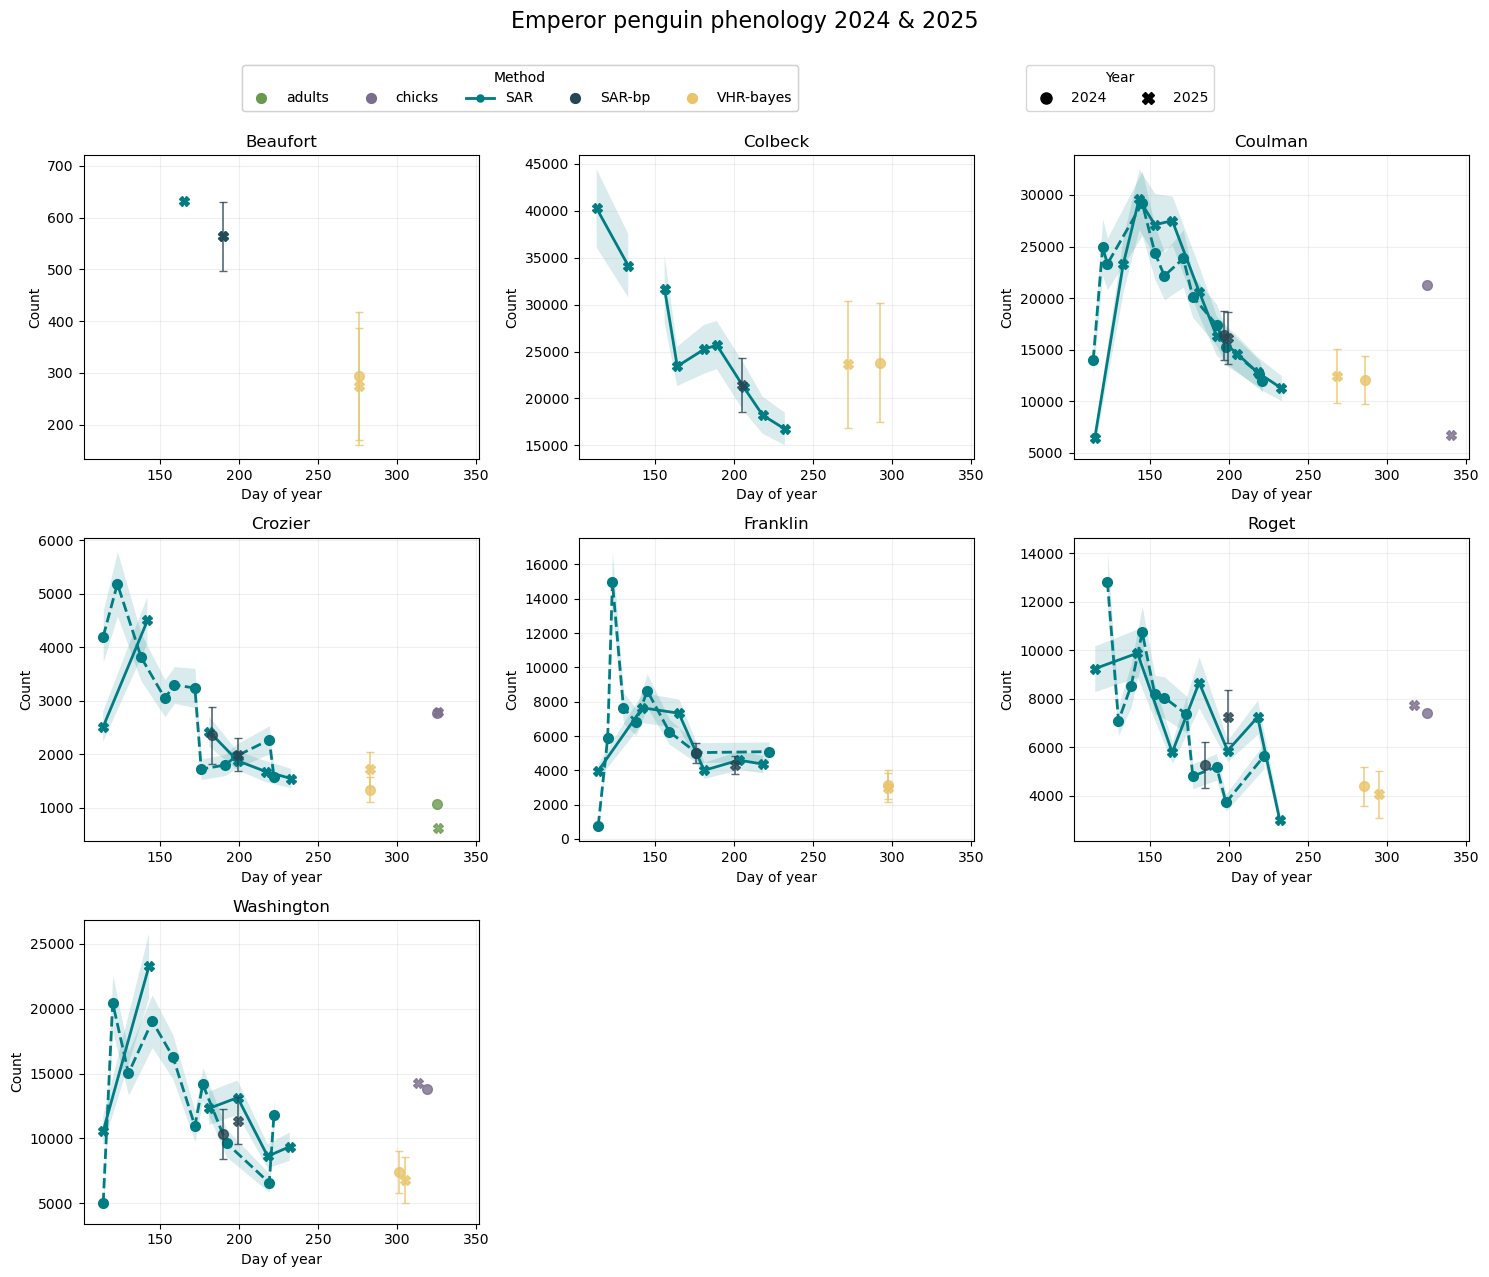

In [44]:
# Get categories
#colonies = filtered_df_RS["colony"].dropna().unique()
colonies = sorted(filtered_df_RS["colony"].dropna().unique()) #order by alphabet
methods = filtered_df_RS["method"].dropna().unique()

# Work out panel layout
n_cols = 3
n_rows = int(np.ceil(len(colonies) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows),
    sharex=True,
    sharey=False
)

years = sorted(filtered_df_RS["year"].dropna().unique())

year_markers = {
    2024: "o",
    2025: "X"
}

year_linestyles = {
    2024: "--",
    2025: "-"
}

# Flatten axes so they are easy to loop through
axes = np.atleast_1d(axes).flatten()

# Assign one colour to each method
#colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
#method_colors = dict(zip(methods, colors))

method_colors = {
    "SAR": "#007C83",        # deep teal
    "SAR-bp": "#264653",     # dark navy
    "VHR-bayes": "#E9C46A",  # golden ochre
    "VHR-rho": "#E76F51",    # coral
    "chicks": "#7B6D8D",     # soft purple
    "adults": "#6A994E"      # sage green
}


# Plot each colony in its own panel
# Plot each colony in its own panel
for ax, colony in zip(axes, colonies):

    df_colony = filtered_df_RS[filtered_df_RS["colony"] == colony]

    for method in methods:

        for year in years:

            df_method_year = df_colony[
                (df_colony["method"] == method) &
                (df_colony["year"] == year)
            ].copy()

            # SAR = line
            if method == "SAR":

                # Sort by day of year so the line connects points correctly
                df_method_year = df_method_year.sort_values("DOY")

                ax.fill_between(
                    df_method_year["DOY"],
                    df_method_year["count"] - df_method_year["count_se"],
                    df_method_year["count"] + df_method_year["count_se"],
                    color=method_colors[method],
                    alpha=0.15,
                    linewidth=0
                )
                ax.plot(
                    df_method_year["DOY"],
                    df_method_year["count"],
                    color=method_colors[method],
                    linewidth=2,
                     linestyle=year_linestyles[year],
                    marker=year_markers[year],
                    markersize=7,
                    label=f"{method} {year}"
                )

            # All other methods = scatter
            #else:

            # All other methods = points + SE bars
            else:

                ax.errorbar(
                    df_method_year["DOY"],
                    df_method_year["count"],
                    yerr=df_method_year["count_se"],
                    fmt=year_markers[year],
                    color=method_colors[method],
                    markersize=7,
                    capsize=3,
                    elinewidth=1.2,
                    markeredgewidth=1,
                    alpha=0.8,
                    linestyle="none",
                    label=f"{method} {year}"
                )

    ax.set_title(colony)
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.2)
    ax.tick_params(axis="x", labelbottom=True)

# Remove unused panels
for ax in axes[len(colonies):]:
    ax.remove()

# One shared legend
handles = []

for method in methods:

    if method == "SAR":

        handle = plt.Line2D(
            [0], [0],
            color=method_colors[method],
            linewidth=2,
            marker="o",
            markersize=5,
            label=method
        )

    else:

        handle = plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            color=method_colors[method],
            markersize=7,
            label=method
        )

    handles.append(handle)


# Method legend — colour
method_handles = []

for method in methods:

    if method == "SAR":

        handle = plt.Line2D(
            [0], [0],
            color=method_colors[method],
            linewidth=2,
            marker="o",
            markersize=5,
            label=method
        )

    else:
        handle = plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            color=method_colors[method],
            markersize=7,
            label=method
        )

    method_handles.append(handle)


# Year legend — marker

year_handles = []

for year in years:

    handle = plt.Line2D(
        [0], [0],
        marker=year_markers[year],
        linestyle="",
        color="black",
        markersize=8,
        label=str(year)
    )

    year_handles.append(handle)


# Add legends

legend1 = fig.legend(
    handles=method_handles,
    title="Method",
    loc="upper center",
    bbox_to_anchor=(0.35, 1.02),
    ncol=len(methods)
)

legend2 = fig.legend(
    handles=year_handles,
    title="Year",
    loc="upper center",
    bbox_to_anchor=(0.75, 1.02),
    ncol=len(years)
)

fig.add_artist(legend1)

fig.suptitle(
    "Emperor penguin phenology 2024 & 2025",
    fontsize=16,
    y=1.06
)

plt.tight_layout()

plt.savefig(os.path.join(INPUTPATH, "Results/all_colonies_RS2425.png"),
            bbox_inches="tight", dpi=600)


plt.show()

____ 

## Recreating above plots but with individual years and combined with se bars and ribbons and new colours 

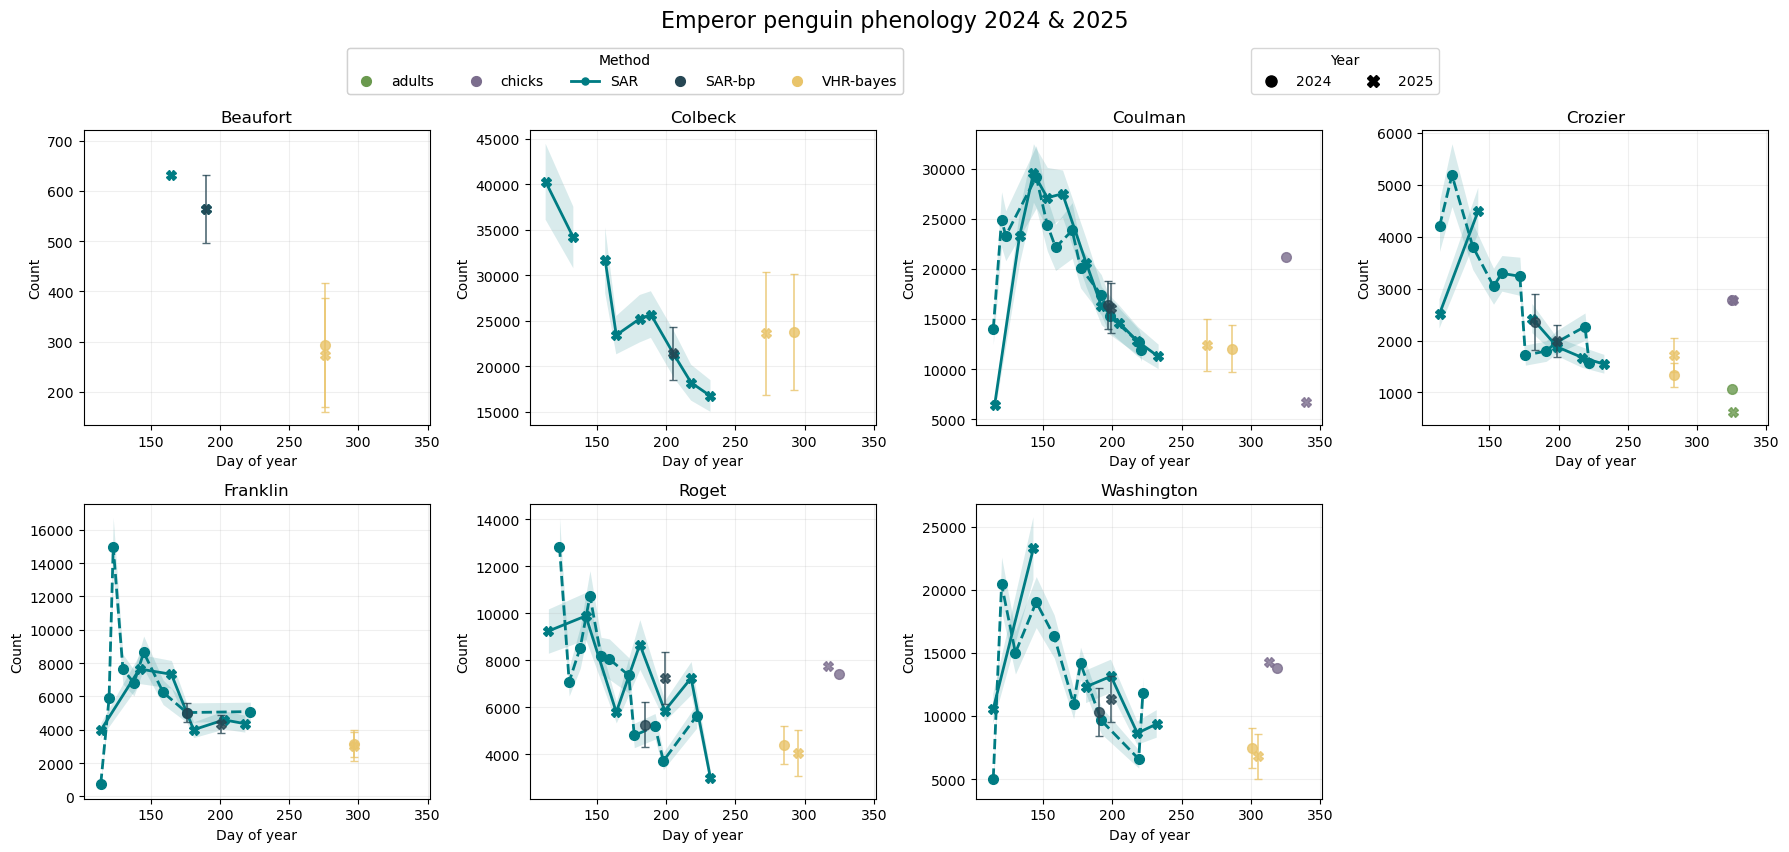

In [41]:
## Let's see if we can put it over 2 rows, rather than 3 

# Get categories
#colonies = filtered_df_RS["colony"].dropna().unique()
colonies = sorted(filtered_df_RS["colony"].dropna().unique()) #order by alphabet
methods = filtered_df_RS["method"].dropna().unique()

# Work out panel layout
n_cols = 4
n_rows = int(np.ceil(len(colonies) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows),
    sharex=True,
    sharey=False
)

years = sorted(filtered_df_RS["year"].dropna().unique())

year_markers = {
    2024: "o",
    2025: "X"
}

year_linestyles = {
    2024: "--",
    2025: "-"
}

# Flatten axes so they are easy to loop through
axes = np.atleast_1d(axes).flatten()

# Assign one colour to each method
#colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
#method_colors = dict(zip(methods, colors))

method_colors = {
    "SAR": "#007C83",        # deep teal
    "SAR-bp": "#264653",     # dark navy
    "VHR-bayes": "#E9C46A",  # golden ochre
    "VHR-rho": "#E76F51",    # coral
    "chicks": "#7B6D8D",     # soft purple
    "adults": "#6A994E"      # sage green
}


# Plot each colony in its own panel
# Plot each colony in its own panel
for ax, colony in zip(axes, colonies):

    df_colony = filtered_df_RS[filtered_df_RS["colony"] == colony]

    for method in methods:

        for year in years:

            df_method_year = df_colony[
                (df_colony["method"] == method) &
                (df_colony["year"] == year)
            ].copy()

            # SAR = line
            if method == "SAR":

                # Sort by day of year so the line connects points correctly
                df_method_year = df_method_year.sort_values("DOY")

                ax.fill_between(
                    df_method_year["DOY"],
                    df_method_year["count"] - df_method_year["count_se"],
                    df_method_year["count"] + df_method_year["count_se"],
                    color=method_colors[method],
                    alpha=0.15,
                    linewidth=0
                )
                ax.plot(
                    df_method_year["DOY"],
                    df_method_year["count"],
                    color=method_colors[method],
                    linewidth=2,
                     linestyle=year_linestyles[year],
                    marker=year_markers[year],
                    markersize=7,
                    label=f"{method} {year}"
                )

            # All other methods = scatter
            #else:

            # All other methods = points + SE bars
            else:

                ax.errorbar(
                    df_method_year["DOY"],
                    df_method_year["count"],
                    yerr=df_method_year["count_se"],
                    fmt=year_markers[year],
                    color=method_colors[method],
                    markersize=7,
                    capsize=3,
                    elinewidth=1.2,
                    markeredgewidth=1,
                    alpha=0.8,
                    linestyle="none",
                    label=f"{method} {year}"
                )

    ax.set_title(colony)
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.2)
    ax.tick_params(axis="x", labelbottom=True)

# Remove unused panels
for ax in axes[len(colonies):]:
    ax.remove()

# One shared legend
handles = []

for method in methods:

    if method == "SAR":

        handle = plt.Line2D(
            [0], [0],
            color=method_colors[method],
            linewidth=2,
            marker="o",
            markersize=5,
            label=method
        )

    else:

        handle = plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            color=method_colors[method],
            markersize=7,
            label=method
        )

    handles.append(handle)


# Method legend — colour
method_handles = []

for method in methods:

    if method == "SAR":

        handle = plt.Line2D(
            [0], [0],
            color=method_colors[method],
            linewidth=2,
            marker="o",
            markersize=5,
            label=method
        )

    else:
        handle = plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            color=method_colors[method],
            markersize=7,
            label=method
        )

    method_handles.append(handle)


# Year legend — marker

year_handles = []

for year in years:

    handle = plt.Line2D(
        [0], [0],
        marker=year_markers[year],
        linestyle="",
        color="black",
        markersize=8,
        label=str(year)
    )

    year_handles.append(handle)


# Add legends

legend1 = fig.legend(
    handles=method_handles,
    title="Method",
    loc="upper center",
    bbox_to_anchor=(0.35, 1.02),
    ncol=len(methods)
)

legend2 = fig.legend(
    handles=year_handles,
    title="Year",
    loc="upper center",
    bbox_to_anchor=(0.75, 1.02),
    ncol=len(years)
)

fig.add_artist(legend1)

fig.suptitle(
    "Emperor penguin phenology 2024 & 2025",
    fontsize=16,
    y=1.06
)

plt.tight_layout()

plt.savefig(os.path.join(INPUTPATH, "Results/all_colonies_RS2425_v2.png"),
            bbox_inches="tight", dpi=600)


plt.show()

____ 

## Adding uncertainty ribbon for each estimate 

Using count_se column 

## ONLY 2024 DATA WITH NO VHR-RHO

We have also removd Colbeck and Beaufort as they have no data other than the VHR estimate

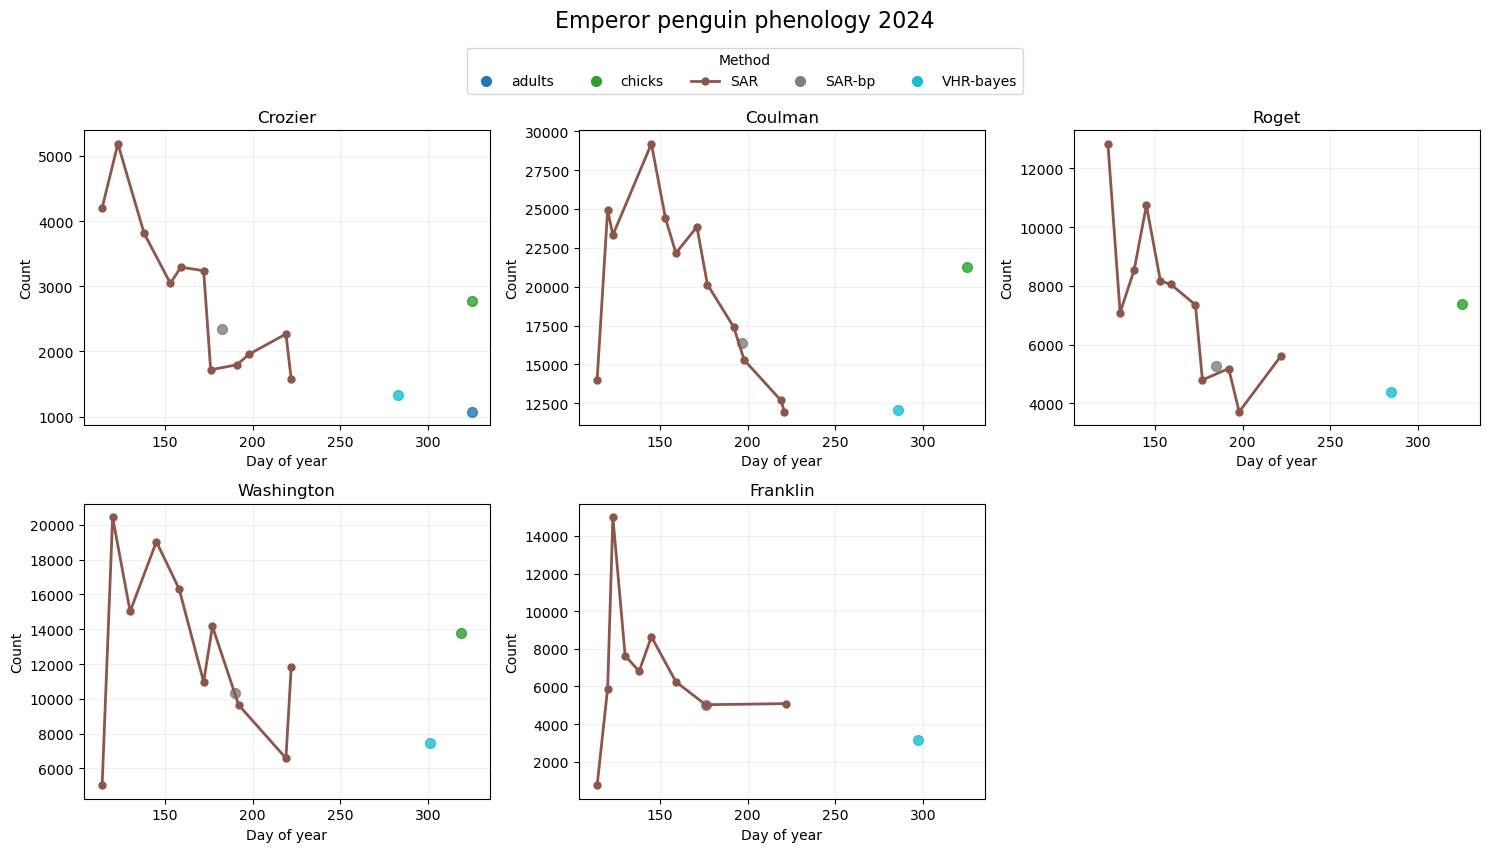

In [29]:
# ONLY 2024 DATA WITH NO VHR-RHO

# Colonies to exclude - NO DATA FOR COLBECK AND BEAUFORT IN 2024 SO LETS REMOVE (only have VHR data and nothing to compare with)
exclude_colonies = ["Colbeck", "Beaufort"]

# Keep only colonies we want to plot
colonies = [
    colony for colony in filtered_df_RS24["colony"].dropna().unique()
    if colony not in exclude_colonies
]

# Get categories
#colonies = filtered_df_RS24["colony"].dropna().unique()
methods = filtered_df_RS24["method"].dropna().unique()

# Work out panel layout
n_cols = 3
n_rows = int(np.ceil(len(colonies) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows),
    sharex=True,
    sharey=False
)

# Flatten axes so they are easy to loop through
axes = np.atleast_1d(axes).flatten()

# Assign one colour to each method
colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
method_colors = dict(zip(methods, colors))

# Plot each colony in its own panel
for ax, colony in zip(axes, colonies):

    df_colony = filtered_df_RS24[filtered_df_RS24["colony"] == colony]

    for method in methods:

        df_method = df_colony[df_colony["method"] == method].copy()

        # SAR = line
        if method == "SAR":

            # Sort by day of year so the line connects points correctly
            df_method = df_method.sort_values("DOY")

            ax.plot(
                df_method["DOY"],
                df_method["count"],
                color=method_colors[method],
                linewidth=2,
                marker="o",
                markersize=5,
                label=method
            )

        # All other methods = scatter
        else:
            ax.scatter(
                df_method["DOY"],
                df_method["count"],
                color=method_colors[method],
                s=50,
                alpha=0.8,
                label=method
            )

    ax.set_title(colony)
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.2)
    ax.tick_params(axis="x", labelbottom=True)
    
# Remove unused panels - let's remove Colbeck and Beaufort 
for ax in axes[len(colonies):]:
    ax.remove()

# One shared legend
handles = []

for method in methods:

    if method == "SAR":
        handle = plt.Line2D(
            [0], [0],
            color=method_colors[method],
            linewidth=2,
            marker="o",
            markersize=5,
            label=method
        )

    else:
        handle = plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            color=method_colors[method],
            markersize=7,
            label=method
        )

    handles.append(handle)

fig.legend(
    handles=handles,
    title="Method",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(methods)
)

fig.suptitle(
    "Emperor penguin phenology 2024",
    fontsize=16,
    y=1.06
)

plt.tight_layout()

plt.savefig(os.path.join(INPUTPATH, "Results/all_colonies_RS24.png"),
            bbox_inches="tight", dpi=600)

plt.show()

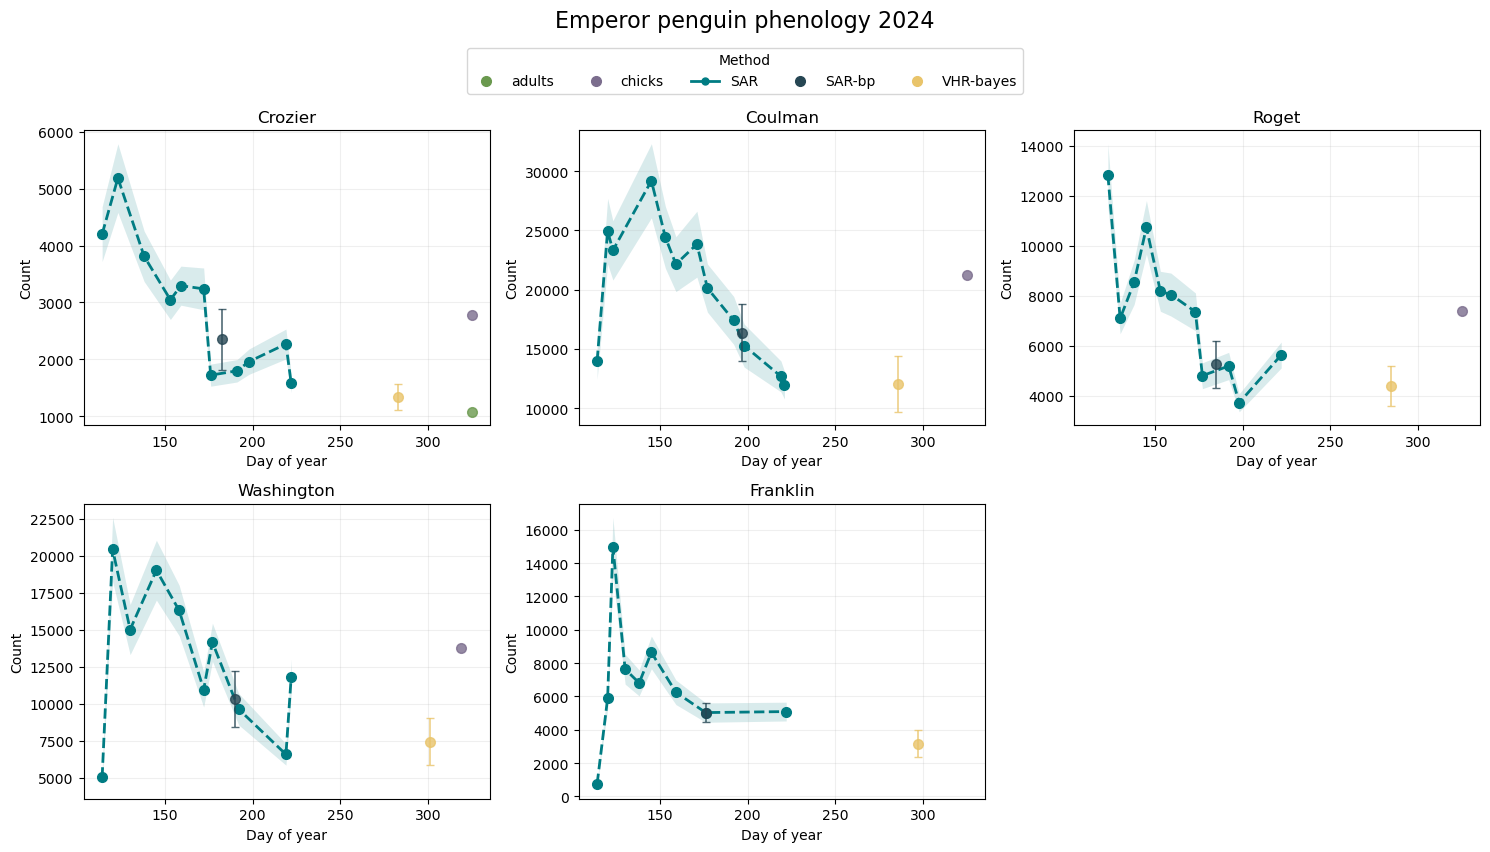

In [47]:
# Get categories

exclude_colonies = ["Colbeck", "Beaufort"]

# Keep only colonies we want to plot
colonies = [
    colony for colony in filtered_df_RS24["colony"].dropna().unique()
    if colony not in exclude_colonies
]

#colonies = filtered_df_RS["colony"].dropna().unique()
#colonies = sorted(filtered_df_RS["colony"].dropna().unique()) #order by alphabet
methods = filtered_df_RS24["method"].dropna().unique()

# Work out panel layout
n_cols = 3
n_rows = int(np.ceil(len(colonies) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows),
    sharex=True,
    sharey=False
)

# Flatten axes so they are easy to loop through
axes = np.atleast_1d(axes).flatten()

# Assign one colour to each method
#colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
#method_colors = dict(zip(methods, colors))

method_colors = {
    "SAR": "#007C83",        # deep teal
    "SAR-bp": "#264653",     # dark navy
    "VHR-bayes": "#E9C46A",  # golden ochre
    "VHR-rho": "#E76F51",    # coral
    "chicks": "#7B6D8D",     # soft purple
    "adults": "#6A994E"      # sage green
}


# Plot each colony in its own panel
# Plot each colony in its own panel
for ax, colony in zip(axes, colonies):

    df_colony = filtered_df_RS24[filtered_df_RS24["colony"] == colony]

    for method in methods:

        for year in years:

            df_method_year = df_colony[
                (df_colony["method"] == method) &
                (df_colony["year"] == year)
            ].copy()

            # SAR = line
            if method == "SAR":

                # Sort by day of year so the line connects points correctly
                df_method_year = df_method_year.sort_values("DOY")

                ax.fill_between(
                    df_method_year["DOY"],
                    df_method_year["count"] - df_method_year["count_se"],
                    df_method_year["count"] + df_method_year["count_se"],
                    color=method_colors[method],
                    alpha=0.15,
                    linewidth=0
                )
                ax.plot(
                    df_method_year["DOY"],
                    df_method_year["count"],
                    color=method_colors[method],
                    linewidth=2,
                     linestyle=year_linestyles[year],
                    marker=year_markers[year],
                    markersize=7,
                    label=f"{method} {year}"
                )

            # All other methods = scatter
            #else:

            # All other methods = points + SE bars
            else:

                ax.errorbar(
                    df_method_year["DOY"],
                    df_method_year["count"],
                    yerr=df_method_year["count_se"],
                    fmt=year_markers[year],
                    color=method_colors[method],
                    markersize=7,
                    capsize=3,
                    elinewidth=1.2,
                    markeredgewidth=1,
                    alpha=0.8,
                    linestyle="none",
                    label=f"{method} {year}"
                )

    ax.set_title(colony)
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.2)
    ax.tick_params(axis="x", labelbottom=True)

# Remove unused panels
for ax in axes[len(colonies):]:
    ax.remove()

# One shared legend
handles = []

for method in methods:

    if method == "SAR":

        handle = plt.Line2D(
            [0], [0],
            color=method_colors[method],
            linewidth=2,
            marker="o",
            markersize=5,
            label=method
        )

    else:

        handle = plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            color=method_colors[method],
            markersize=7,
            label=method
        )

    handles.append(handle)


# Method legend — colour
method_handles = []

for method in methods:

    if method == "SAR":

        handle = plt.Line2D(
            [0], [0],
            color=method_colors[method],
            linewidth=2,
            marker="o",
            markersize=5,
            label=method
        )

    else:
        handle = plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            color=method_colors[method],
            markersize=7,
            label=method
        )

    method_handles.append(handle)


# Year legend — marker

year_handles = []

for year in years:

    handle = plt.Line2D(
        [0], [0],
        marker=year_markers[year],
        linestyle="",
        color="black",
        markersize=8,
        label=str(year)
    )

    year_handles.append(handle)


# Add legends
fig.legend(
    handles=handles,
    title="Method",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(methods)
)

fig.suptitle(
    "Emperor penguin phenology 2024",
    fontsize=16,
    y=1.06
)


plt.tight_layout()

plt.savefig(os.path.join(INPUTPATH, "Results/all_colonies_RS24_v2.png"),
            bbox_inches="tight", dpi=600)


plt.show()

## ONLY 2025 DATA PLOTTED

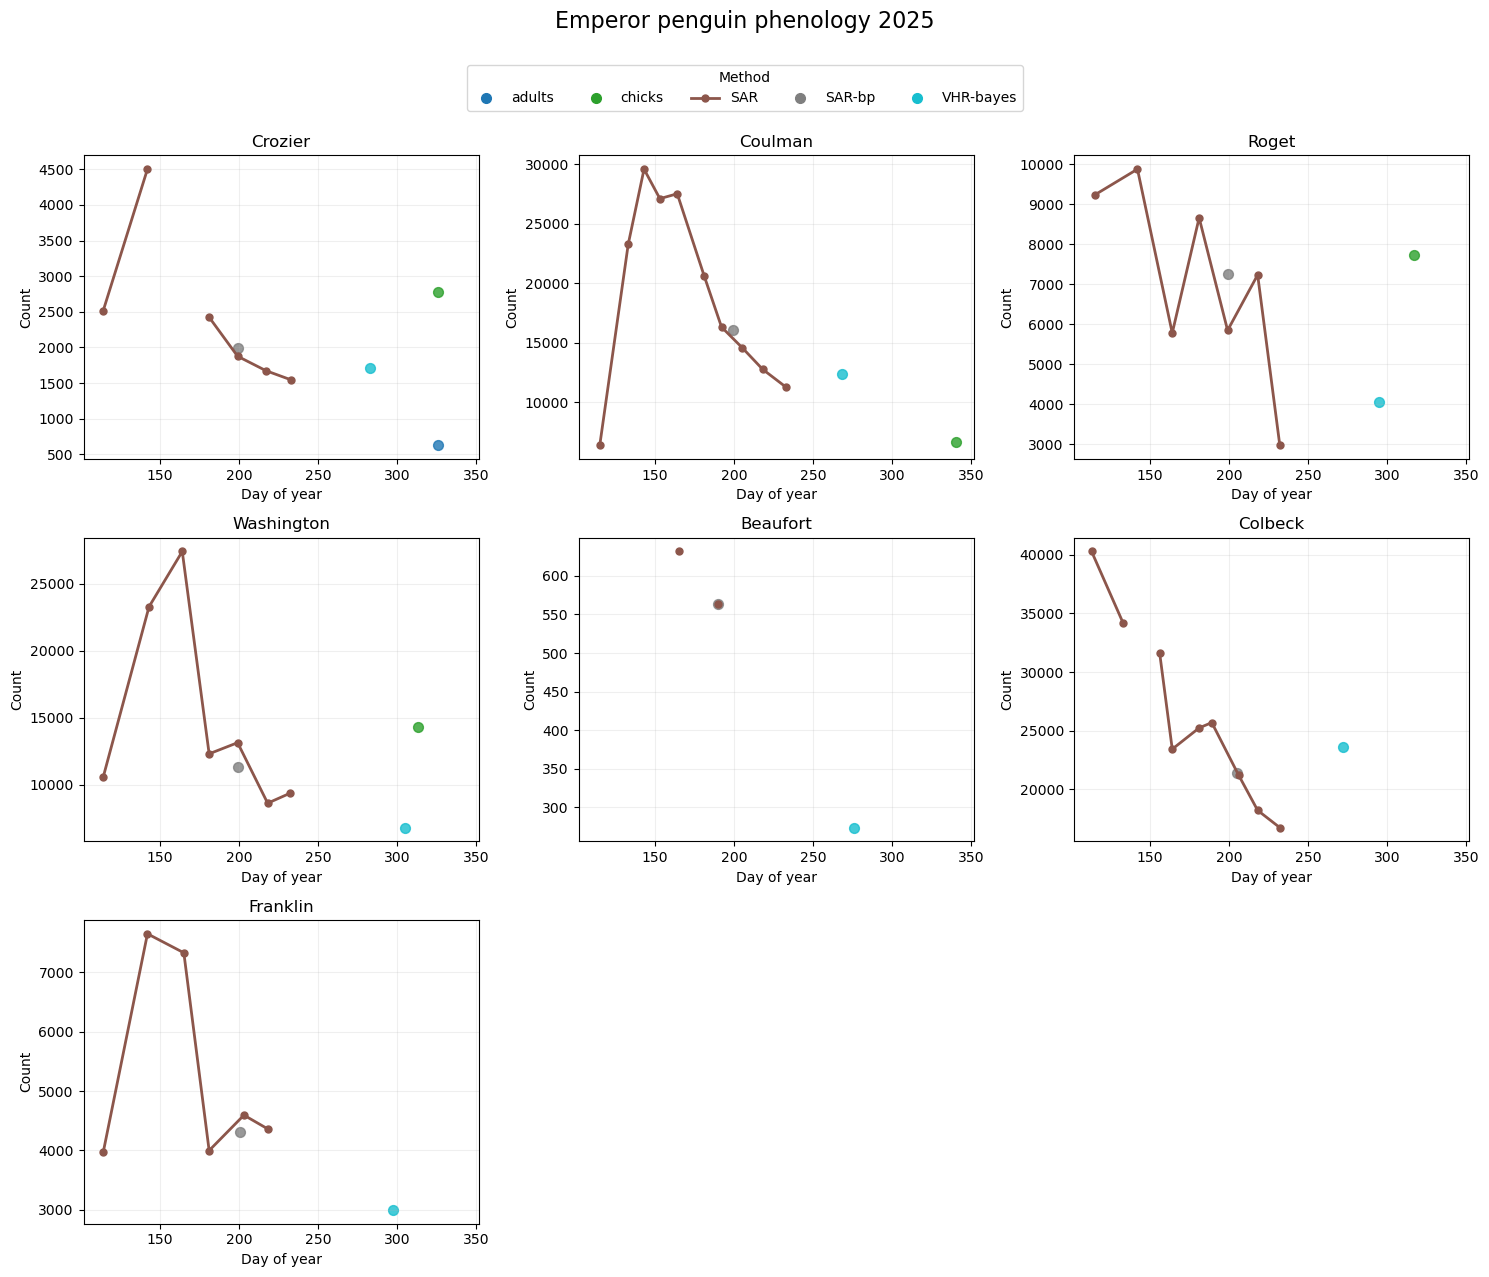

In [30]:
# ONLY 2025 DATA WITH NO VHR-RHO
# Get categories
colonies = filtered_df_RS25["colony"].dropna().unique()
methods = filtered_df_RS25["method"].dropna().unique()

# Work out panel layout
n_cols = 3
n_rows = int(np.ceil(len(colonies) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows),
    sharex=True,
    sharey=False
)

# Flatten axes so they are easy to loop through
axes = np.atleast_1d(axes).flatten()

# Assign one colour to each method
colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
method_colors = dict(zip(methods, colors))

# Plot each colony in its own panel
for ax, colony in zip(axes, colonies):

    df_colony = filtered_df_RS25[filtered_df_RS25["colony"] == colony]

    for method in methods:

        df_method = df_colony[df_colony["method"] == method].copy()

        # SAR = line
        if method == "SAR":

            # Sort by day of year so the line connects points correctly
            df_method = df_method.sort_values("DOY")

            ax.plot(
                df_method["DOY"],
                df_method["count"],
                color=method_colors[method],
                linewidth=2,
                marker="o",
                markersize=5,
                label=method
            )

        # All other methods = scatter
        else:

            ax.scatter(
                df_method["DOY"],
                df_method["count"],
                color=method_colors[method],
                s=50,
                alpha=0.8,
                label=method
            )

    ax.set_title(colony)
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.2)
    ax.tick_params(axis="x", labelbottom=True)


# Remove unused panels
for ax in axes[len(colonies):]:
    ax.remove()

# One shared legend
handles = []

for method in methods:

    if method == "SAR":

        handle = plt.Line2D(
            [0], [0],
            color=method_colors[method],
            linewidth=2,
            marker="o",
            markersize=5,
            label=method
        )

    else:

        handle = plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            color=method_colors[method],
            markersize=7,
            label=method
        )

    handles.append(handle)

fig.legend(
    handles=handles,
    title="Method",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(methods)
)

fig.suptitle(
    "Emperor penguin phenology 2025",
    fontsize=16,
    y=1.06
)

plt.tight_layout()

plt.savefig(os.path.join(INPUTPATH, "Results/all_colonies_RS25.png"),
            bbox_inches="tight", dpi=600)

plt.show()

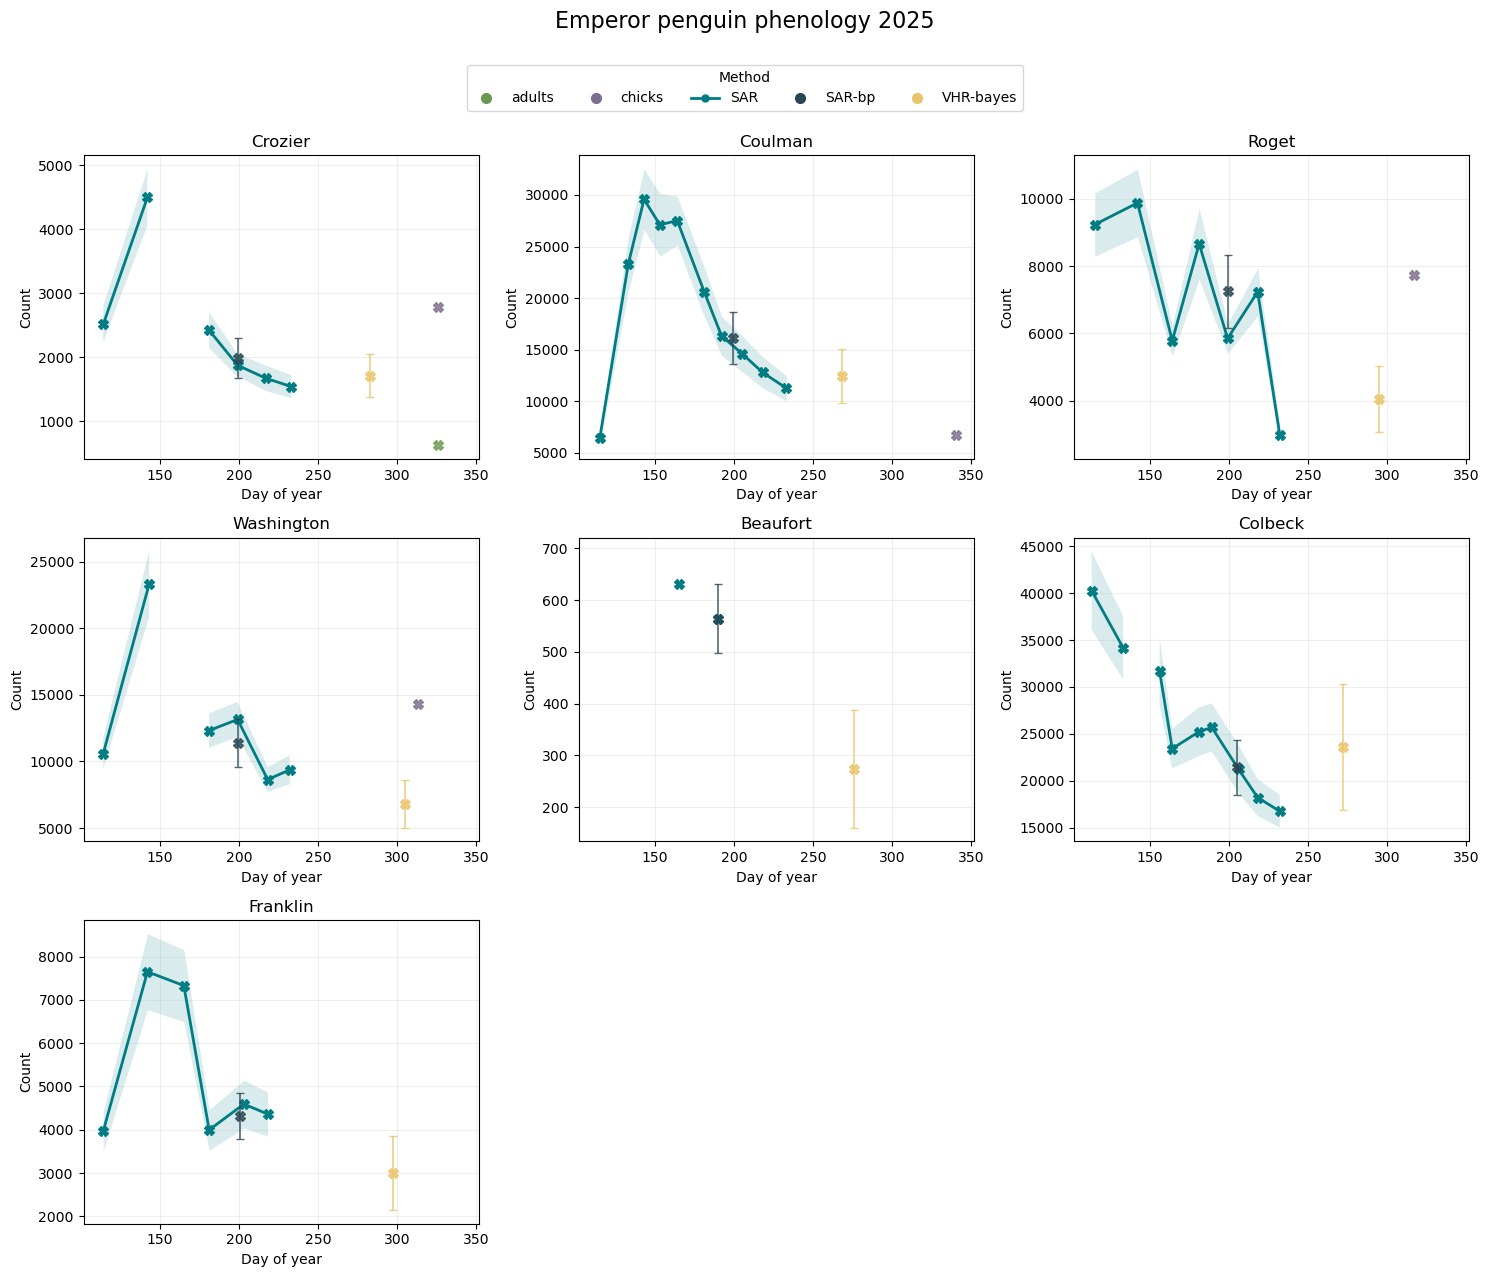

In [48]:
# ONLY 2025 DATA WITH NO VHR-RHO
# Get categories
colonies = filtered_df_RS25["colony"].dropna().unique()
methods = filtered_df_RS25["method"].dropna().unique()


# Work out panel layout
n_cols = 3
n_rows = int(np.ceil(len(colonies) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows),
    sharex=True,
    sharey=False
)

# Flatten axes so they are easy to loop through
axes = np.atleast_1d(axes).flatten()

# Assign one colour to each method
#colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
#method_colors = dict(zip(methods, colors))

method_colors = {
    "SAR": "#007C83",        # deep teal
    "SAR-bp": "#264653",     # dark navy
    "VHR-bayes": "#E9C46A",  # golden ochre
    "VHR-rho": "#E76F51",    # coral
    "chicks": "#7B6D8D",     # soft purple
    "adults": "#6A994E"      # sage green
}


# Plot each colony in its own panel
# Plot each colony in its own panel
for ax, colony in zip(axes, colonies):

    df_colony = filtered_df_RS25[filtered_df_RS25["colony"] == colony]

    for method in methods:

        for year in years:

            df_method_year = df_colony[
                (df_colony["method"] == method) &
                (df_colony["year"] == year)
            ].copy()

            # SAR = line
            if method == "SAR":

                # Sort by day of year so the line connects points correctly
                df_method_year = df_method_year.sort_values("DOY")

                ax.fill_between(
                    df_method_year["DOY"],
                    df_method_year["count"] - df_method_year["count_se"],
                    df_method_year["count"] + df_method_year["count_se"],
                    color=method_colors[method],
                    alpha=0.15,
                    linewidth=0
                )
                ax.plot(
                    df_method_year["DOY"],
                    df_method_year["count"],
                    color=method_colors[method],
                    linewidth=2,
                     linestyle=year_linestyles[year],
                    marker=year_markers[year],
                    markersize=7,
                    label=f"{method} {year}"
                )

            # All other methods = scatter
            #else:

            # All other methods = points + SE bars
            else:

                ax.errorbar(
                    df_method_year["DOY"],
                    df_method_year["count"],
                    yerr=df_method_year["count_se"],
                    fmt=year_markers[year],
                    color=method_colors[method],
                    markersize=7,
                    capsize=3,
                    elinewidth=1.2,
                    markeredgewidth=1,
                    alpha=0.8,
                    linestyle="none",
                    label=f"{method} {year}"
                )

    ax.set_title(colony)
    ax.set_xlabel("Day of year")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.2)
    ax.tick_params(axis="x", labelbottom=True)

# Remove unused panels
for ax in axes[len(colonies):]:
    ax.remove()

# One shared legend
handles = []

for method in methods:

    if method == "SAR":

        handle = plt.Line2D(
            [0], [0],
            color=method_colors[method],
            linewidth=2,
            marker="o",
            markersize=5,
            label=method
        )

    else:

        handle = plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            color=method_colors[method],
            markersize=7,
            label=method
        )

    handles.append(handle)


# Method legend — colour
method_handles = []

for method in methods:

    if method == "SAR":

        handle = plt.Line2D(
            [0], [0],
            color=method_colors[method],
            linewidth=2,
            marker="o",
            markersize=5,
            label=method
        )

    else:
        handle = plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            color=method_colors[method],
            markersize=7,
            label=method
        )

    method_handles.append(handle)


# Year legend — marker

year_handles = []

for year in years:

    handle = plt.Line2D(
        [0], [0],
        marker=year_markers[year],
        linestyle="",
        color="black",
        markersize=8,
        label=str(year)
    )

    year_handles.append(handle)


# Add legends
fig.legend(
    handles=handles,
    title="Method",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(methods)
)

fig.suptitle(
    "Emperor penguin phenology 2025",
    fontsize=16,
    y=1.06
)


plt.tight_layout()

plt.savefig(os.path.join(INPUTPATH, "Results/all_colonies_RS25_v2.png"),
            bbox_inches="tight", dpi=600)


plt.show()

## Let's try individual plots per location again

So we can better see patterns


Definitely need to remove VHR-rho

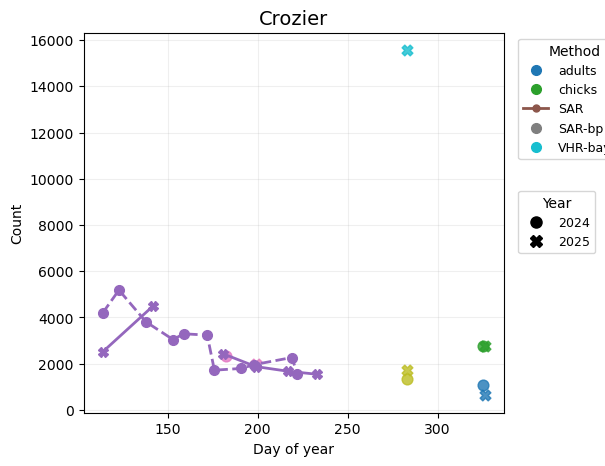

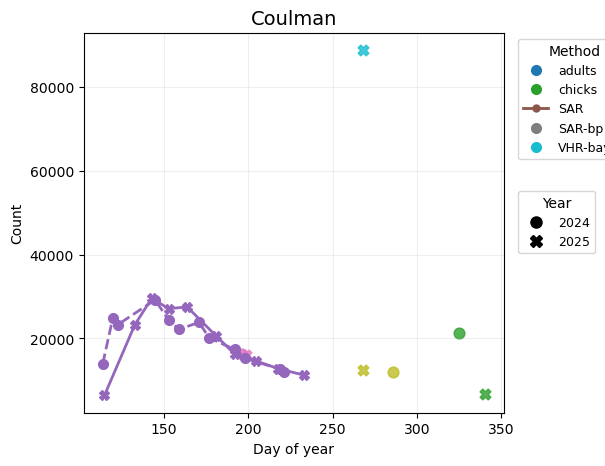

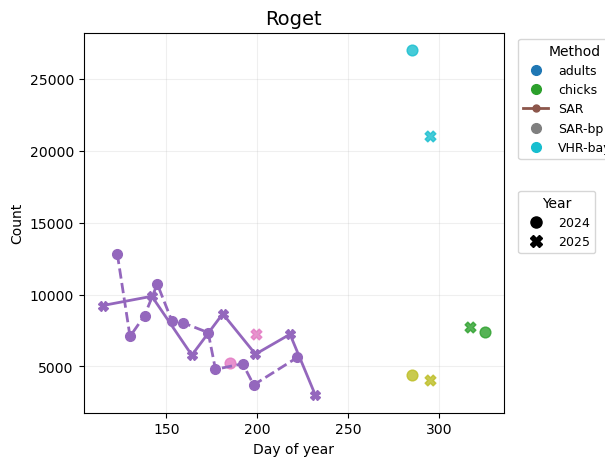

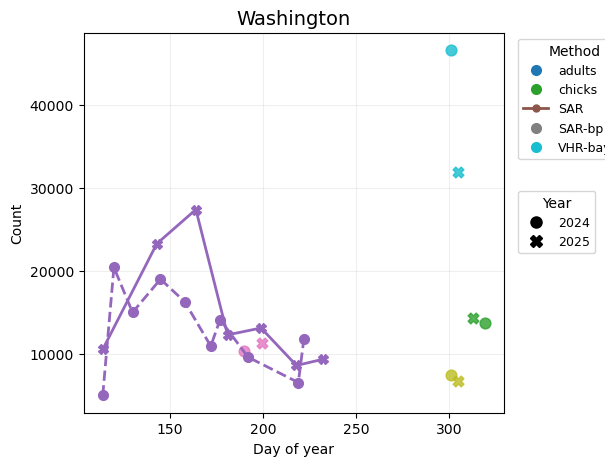

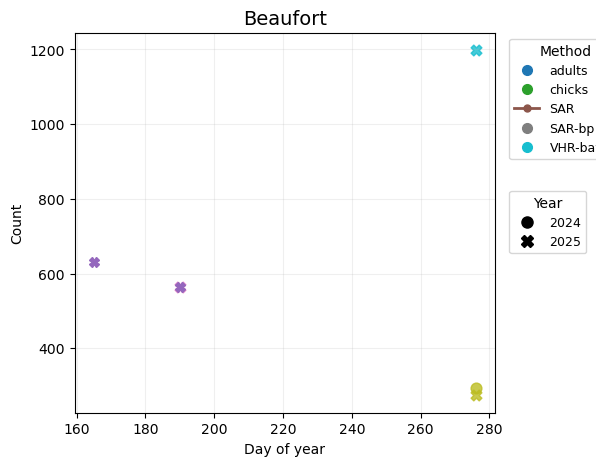

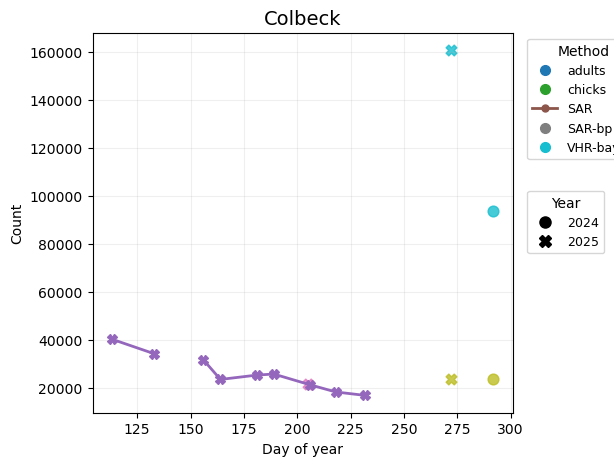

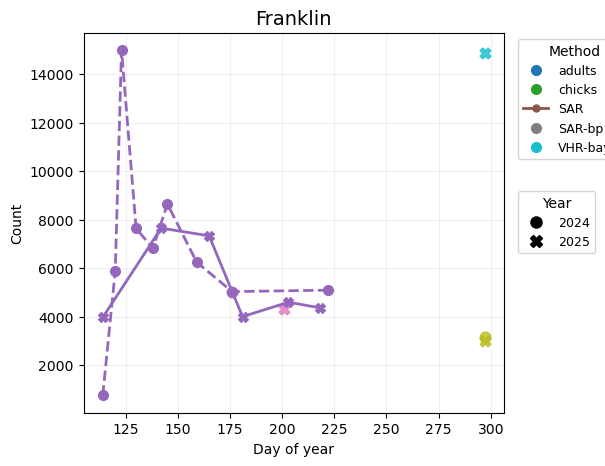

In [ ]:
# Get categories
colonies = df_RossSea["colony"].dropna().unique()
methods = df_RossSea["method"].dropna().unique()
years = sorted(df_RossSea["year"].dropna().unique())

# ---------------------------------------------------------
# Formatting
# ---------------------------------------------------------

year_markers = {
    2024: "o",
    2025: "X"
}

year_linestyles = {
    2024: "--",
    2025: "-"
}

# Keep method colours consistent across all figures
colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
method_colors = dict(zip(methods, colors))


# ---------------------------------------------------------
# Make one figure per colony
# ---------------------------------------------------------

for colony in colonies:

    # Create a new figure for this colony
    fig, ax = plt.subplots(figsize=(7, 5))

    # Subset data for this colony
    df_colony = df_RossSea[
        df_RossSea["colony"] == colony
    ]

    # -----------------------------------------------------
    # Plot each method and year
    # -----------------------------------------------------

    for method in methods:

        for year in years:

            df_method_year = df_colony[
                (df_colony["method"] == method) &
                (df_colony["year"] == year)
            ].copy()

            # Skip if there are no data for this
            # method/year combination
            if df_method_year.empty:
                continue

            # -------------------------------------------------
            # SAR = line
            # -------------------------------------------------

            if method == "SAR":

                # Sort by DOY so the line connects correctly
                df_method_year = df_method_year.sort_values("DOY")

                ax.plot(
                    df_method_year["DOY"],
                    df_method_year["count"],
                    color=method_colors[method],
                    linewidth=2,
                    linestyle=year_linestyles[year],
                    marker=year_markers[year],
                    markersize=7
                )

            # -------------------------------------------------
            # Other methods = scatter
            # -------------------------------------------------

            else:

                ax.scatter(
                    df_method_year["DOY"],
                    df_method_year["count"],
                    color=method_colors[method],
                    marker=year_markers[year],
                    s=60,
                    alpha=0.8
                )

    # ---------------------------------------------------------
    # Axes formatting
    # ---------------------------------------------------------

    ax.set_title(colony, fontsize=14)

    ax.set_xlabel("Day of year")
    ax.set_ylabel("Count")

    ax.grid(alpha=0.2)
    

    # Show x-axis labels
    ax.tick_params(axis="x", labelbottom=True)


    # ---------------------------------------------------------
    # Method legend
    # ---------------------------------------------------------

        # Method legend
    legend1 = ax.legend(
        handles=method_handles,
        title="Method",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        frameon=True,
        fontsize=9,
        title_fontsize=10
    )

    # Year legend
    legend2 = ax.legend(
        handles=year_handles,
        title="Year",
        loc="upper left",
        bbox_to_anchor=(1.02, 0.60),
        frameon=True,
        fontsize=9,
        title_fontsize=10
    )

    ax.add_artist(legend1)


    # Don't use tight_layout()
    fig.subplots_adjust(
        left=0.10,
        right=0.70,
        bottom=0.12,
        top=0.88
    )

    # ---------------------------------------------------------
    # Save individual figure
    # ---------------------------------------------------------

    filename = os.path.join(
        INPUTPATH,
        f"Results/{colony}_RS2425_alldata.png"
    )


    plt.savefig(
        filename,
        #bbox_inches="tight",
        dpi=600
    )

    plt.show()

    # Close figure before moving to the next colony
    plt.close(fig)




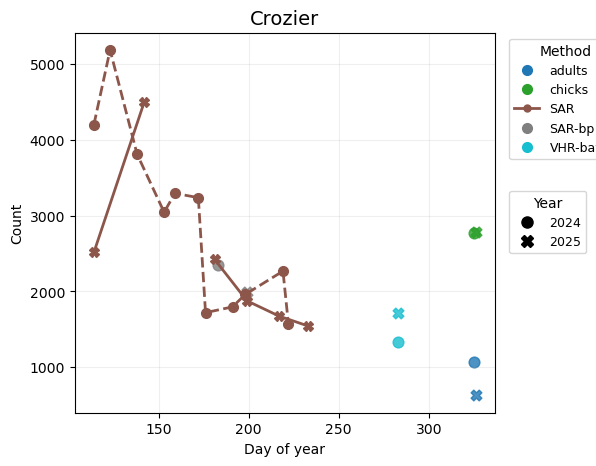

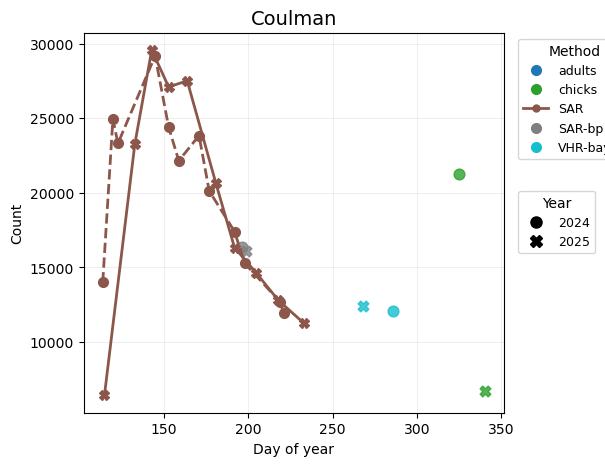

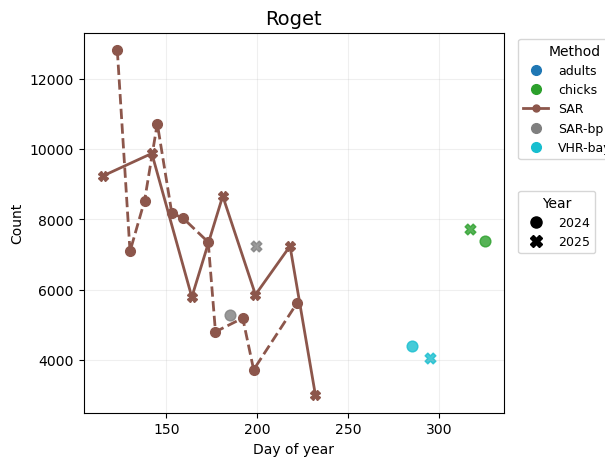

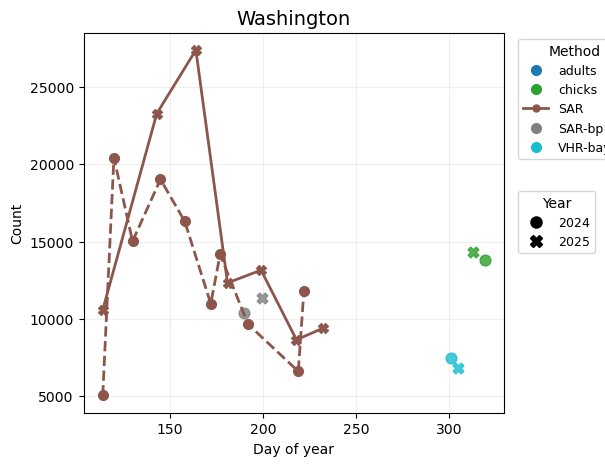

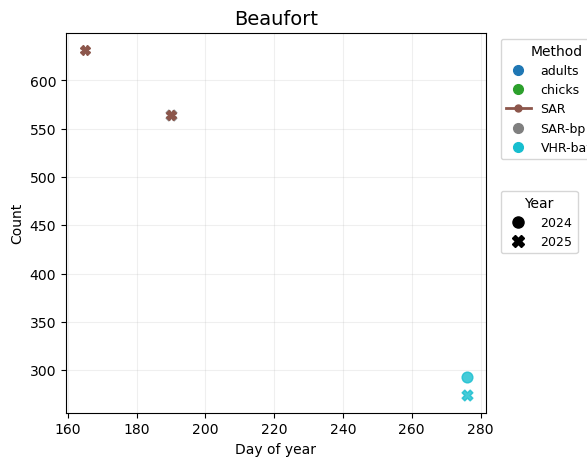

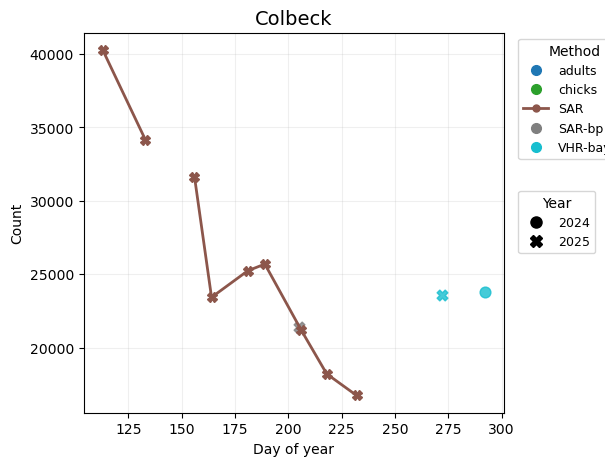

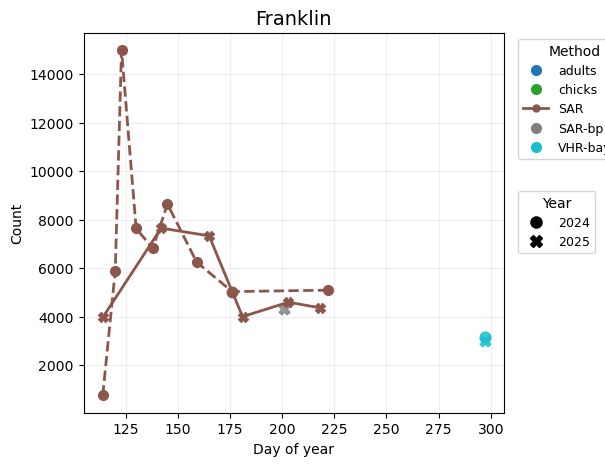

In [32]:
# Get categories
colonies = filtered_df_RS["colony"].dropna().unique()
methods = filtered_df_RS["method"].dropna().unique()
years = sorted(filtered_df_RS["year"].dropna().unique())

# ---------------------------------------------------------
# Formatting
# ---------------------------------------------------------

year_markers = {
    2024: "o",
    2025: "X"
}

year_linestyles = {
    2024: "--",
    2025: "-"
}

# Keep method colours consistent across all figures
colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
method_colors = dict(zip(methods, colors))


# ---------------------------------------------------------
# Make one figure per colony
# ---------------------------------------------------------

for colony in colonies:

    # Create a new figure for this colony
    fig, ax = plt.subplots(figsize=(7, 5))

    # Subset data for this colony
    df_colony = filtered_df_RS[
        filtered_df_RS["colony"] == colony
    ]

    # -----------------------------------------------------
    # Plot each method and year
    # -----------------------------------------------------

    for method in methods:

        for year in years:

            df_method_year = df_colony[
                (df_colony["method"] == method) &
                (df_colony["year"] == year)
            ].copy()

            # Skip if there are no data for this
            # method/year combination
            if df_method_year.empty:
                continue

            # -------------------------------------------------
            # SAR = line
            # -------------------------------------------------

            if method == "SAR":

                # Sort by DOY so the line connects correctly
                df_method_year = df_method_year.sort_values("DOY")

                ax.plot(
                    df_method_year["DOY"],
                    df_method_year["count"],
                    color=method_colors[method],
                    linewidth=2,
                    linestyle=year_linestyles[year],
                    marker=year_markers[year],
                    markersize=7
                )

            # -------------------------------------------------
            # Other methods = scatter
            # -------------------------------------------------

            else:

                ax.scatter(
                    df_method_year["DOY"],
                    df_method_year["count"],
                    color=method_colors[method],
                    marker=year_markers[year],
                    s=60,
                    alpha=0.8
                )

    # ---------------------------------------------------------
    # Axes formatting
    # ---------------------------------------------------------

    ax.set_title(colony, fontsize=14)

    ax.set_xlabel("Day of year")
    ax.set_ylabel("Count")

    ax.grid(alpha=0.2)
    

    # Show x-axis labels
    ax.tick_params(axis="x", labelbottom=True)


    # ---------------------------------------------------------
    # Method legend
    # ---------------------------------------------------------

        # Method legend
    legend1 = ax.legend(
        handles=method_handles,
        title="Method",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        frameon=True,
        fontsize=9,
        title_fontsize=10
    )

    # Year legend
    legend2 = ax.legend(
        handles=year_handles,
        title="Year",
        loc="upper left",
        bbox_to_anchor=(1.02, 0.60),
        frameon=True,
        fontsize=9,
        title_fontsize=10
    )

    ax.add_artist(legend1)


    # Don't use tight_layout()
    fig.subplots_adjust(
        left=0.10,
        right=0.70,
        bottom=0.12,
        top=0.88
    )

    # ---------------------------------------------------------
    # Save individual figure
    # ---------------------------------------------------------

    filename = os.path.join(
        INPUTPATH,
        f"Results/{colony}_RS2425_noVHRrho.png"
    )


    plt.savefig(
        filename,
        #bbox_inches="tight",
        dpi=600
    )

    plt.show()

    # Close figure before moving to the next colony
    plt.close(fig)

